In [105]:
#!pip install leidenalg powerlaw pyreadr rdata

In [106]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from tqdm import tqdm
import igraph as ig
import powerlaw
import leidenalg as la

# plotting defaults
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.dpi"] = 150

RNG = np.random.default_rng(42)

ROOT = Path("Pixar Rdata")      
OUT  = ROOT / "Outputs"

In [107]:
# ---------- Robust RData loader (pyreadr first, rdata fallback) ----------
try:
    import pyreadr  # fast path for clean UTF-8
    _HAS_PYREADR = True
except Exception:
    _HAS_PYREADR = False

import rdata

ENCODING_CANDIDATES = ["utf-8", "latin1", "cp1252", "mac_roman"]

def _convert_rdata_to_python(path: Path, default_encoding: str, force: bool = True):
    parsed = rdata.parser.parse_file(str(path))
    return rdata.conversion.convert(parsed, default_encoding=default_encoding, force_default_encoding=force)

def _coerce_to_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj
    try:
        return pd.DataFrame(obj)
    except Exception:
        return obj

def _clean_strings_in_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            s = df[col].astype(str)
            # quick ‘mojibake’ sniff (U+FFFD seen)
            if any('\ufffd' in x for x in s.head(100)):
                for enc in ("latin1", "cp1252", "mac_roman"):
                    try:
                        fixed = s.str.encode(enc, errors="ignore").str.decode("utf-8", errors="ignore")
                        df[col] = fixed
                        break
                    except Exception:
                        continue
    return df

def load_rdata_dict(path: Path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if _HAS_PYREADR:
        try:
            res = pyreadr.read_r(str(path))
            return {k: _coerce_to_df(v) for k, v in res.items()}
        except UnicodeDecodeError as e:
            warnings.warn(f"pyreadr failed (Unicode); falling back to rdata. {e}")
        except Exception as e:
            warnings.warn(f"pyreadr failed; falling back to rdata. {e}")

    last_err = None
    for enc in ENCODING_CANDIDATES:
        try:
            converted = _convert_rdata_to_python(path, default_encoding=enc, force=True)
            out = {k: _coerce_to_df(v) for k, v in converted.items()}
            return {k: (_clean_strings_in_df(v) if isinstance(v, pd.DataFrame) else v) for k, v in out.items()}
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(f"Failed to load {path} with encodings {ENCODING_CANDIDATES}. Last error: {last_err}")

In [108]:
import warnings
# Suppress known warnings from rdata when loading RData files to keep the code clean

# 1) Your own message raised via warnings.warn(...)
warnings.filterwarnings(
    "ignore",
    message=r".*pyreadr failed \(Unicode\); falling back to rdata.*",
    category=UserWarning
)

# 2a) rdata decode warnings (module-qualified)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"rdata\.conversion\._conversion",
    message=r"Exception while decoding .*: 'utf-8' codec can't decode.*"
)

# 2b) rdata "Missing constructor for R class \"data.table\""
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"rdata\.conversion\._conversion",
    message=r"Missing constructor for R class \"data\.table\".*"
)


In [109]:
posts_map    = load_rdata_dict(ROOT / "posts_disneypixar.rdata")
likes_map    = load_rdata_dict(ROOT / "likes_disneypixar.rdata")
comments_map = load_rdata_dict(ROOT / "comments_disneypixar.rdata")

def pick_table(d):
    for key in ("posts", "likes", "comments"):
        if key in d and isinstance(d[key], pd.DataFrame):
            return d[key]
    for _, v in d.items():
        if isinstance(v, pd.DataFrame):
            return v
    # fallback: first object
    return next(iter(d.values()))

posts    = pick_table(posts_map)
likes    = pick_table(likes_map)
comments = pick_table(comments_map)

for name, df in [("posts", posts), ("likes", likes), ("comments", comments)]:
    print(name, type(df), getattr(df, "shape", None))

display(posts.head(3) if isinstance(posts, pd.DataFrame) else posts)
display(likes.head(3) if isinstance(likes, pd.DataFrame) else likes)
display(comments.head(3) if isinstance(comments, pd.DataFrame) else comments)

posts <class 'pandas.core.frame.DataFrame'> (581, 12)
likes <class 'pandas.core.frame.DataFrame'> (1077071, 3)
comments <class 'pandas.core.frame.DataFrame'> (50422, 8)


,from_id,from_name,message,created_time,type,link,post_id,story,likes_count,comments_count,shares_count,page_id
1,3.524593e+10,Disney Pixar,Ring in the resolutions.,2016-12-31T22:30:29+0000,video,https://www.facebook.com/DisneyPixar/videos/10...,35245929077_10154976061679078,,3211,103,763,35245929077
2,3.524593e+10,Disney Pixar,"New year, new friends.",2016-12-31T18:00:01+0000,photo,https://www.facebook.com/DisneyPixar/photos/a....,35245929077_10154975271164078,,1416,13,39,35245929077
3,3.524593e+10,Disney Pixar,A sight to sea!,2016-12-30T20:30:38+0000,video,https://www.facebook.com/DisneyPixar/videos/10...,35245929077_10154972466094078,,714,3,14,35245929077


,from_id,post_id,page_id
0,10155055802231814,35245929077_10154976061679078,35245929077
1,1913166545367332,35245929077_10154976061679078,35245929077
2,10213649400980014,35245929077_10154976061679078,35245929077


,from_id,message,created_time,likes_count,comments_count,comment_id,post_id,page_id
1,454133027935641,My New Year's resolution: To take that evil wi...,2017-01-01T10:06:35+0000,1.0,0.0,10154976061679078_10154977899474078,35245929077_10154976061679078,35245929077
2,10214341975883015,Josephine Josefine lad det aldrig blive mandag...,2017-01-01T11:57:26+0000,3.0,0.0,10154976061679078_10154978099394078,35245929077_10154976061679078,35245929077
3,10154960253381409,Anh VÅ© táº­p gym Äá»«ng set mÃ¡y cháº¡y nhan...,2017-01-01T13:14:26+0000,2.0,4.0,10154976061679078_10154978257764078,35245929077_10154976061679078,35245929077


In [110]:
RENAME = {
    'post.id': 'post_id', 'from.id': 'from_id',
    'postId': 'post_id',  'fromId': 'from_id'
}
def normalize_ids(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns}).copy()
    assert {'post_id','from_id'}.issubset(df.columns), "Missing required columns {'post_id','from_id'}"
    # keep only what we need; cast to string for stable node keys
    df = df[['post_id','from_id']].dropna()
    df['post_id'] = df['post_id'].astype(str)
    df['from_id'] = df['from_id'].astype(str)
    return df

likes    = normalize_ids(likes)
comments = normalize_ids(comments)

In [111]:
# sampling ram / plot safely
MAX_COMMENT_EDGES = 5_000 
MAX_LIKE_EDGES    = 50_000
likes_sample    = likes.head(MAX_LIKE_EDGES).copy()
comments_sample = comments.head(MAX_COMMENT_EDGES).copy()

### **Building a Fast Bipartite Network for Social Data**

In social media analysis, we often need to represent interactions — for example, which users liked or commented on which posts — as a **bipartite graph**.  
One set of nodes corresponds to **posts**, and the other to **users**. Edges connect users to the posts they interacted with, optionally carrying weights that represent interaction frequency.

The approach below focuses on **speed and scalability**, efficiently constructing a weighted bipartite graph using vectorized NumPy and pandas operations.  
It’s designed for **large datasets** (like millions of likes or comments) and outputs a ready-to-analyze `igraph` object with clear vertex attributes (`type`, `role`, `name`) and edge weights.

An additional helper prepares the graph for visualization in **Gephi**, labeling only the most connected nodes (top-degree vertices) to maintain readability in dense networks.


In [112]:
def build_bipartite_igraph_fast(
    df: pd.DataFrame,
    post_col: str = "post_id",
    user_col: str = "from_id",
    max_rows: int | None = None,
    coerce_str: bool = True,
):
    """
    Fast weighted bipartite:
    - Dedup (post,user) pairs via NumPy unique (edge 'weight' = multiplicity)
    - Node order: [all posts..., all users...]
    - Vertex attrs: name, type(False=post, True=user), role('post'/'user')
    """
    x = df[[post_col, user_col]].dropna()
    if max_rows is not None:
        x = x.iloc[:max_rows]

    if coerce_str:
        posts_raw = x[post_col].astype(str).to_numpy()
        users_raw = x[user_col].astype(str).to_numpy()
    else:
        posts_raw = x[post_col].to_numpy()
        users_raw = x[user_col].to_numpy()

    # factorize separately (O(n))
    post_codes, post_labels = pd.factorize(posts_raw, sort=False)
    user_codes, user_labels = pd.factorize(users_raw, sort=False)

    # dedup pairs and count multiplicity
    pairs = np.column_stack((post_codes, user_codes))
    view_dt = np.dtype([("p", pairs.dtype), ("u", pairs.dtype)])
    uniq_struct, counts = np.unique(pairs.view(view_dt).ravel(), return_counts=True)
    uniq = uniq_struct.view(pairs.dtype).reshape(-1, 2)

    n_posts = len(post_labels)
    n_users = len(user_labels)
    edges_src = uniq[:, 0]
    edges_dst = uniq[:, 1] + n_posts

    G = ig.Graph(n=n_posts + n_users, edges=list(zip(edges_src, edges_dst)), directed=False)
    G.vs["name"] = np.concatenate([post_labels, user_labels]).tolist()
    types = np.zeros(G.vcount(), dtype=bool); types[n_posts:] = True
    G.vs["type"] = types.tolist()
    G.vs["role"] = np.where(types, "user", "post").tolist()
    G.es["weight"] = counts.astype(int).tolist()

    # Defensive (already simple)
    G.simplify(multiple=True, loops=True, combine_edges={"weight": "sum"})
    return G, post_labels, user_labels

def add_labels_for_gephi(g: ig.Graph, top_n=60):
    g = g.copy()
    deg = g.degree()
    g.vs['degree'] = deg
    g.vs['label'] = [''] * g.vcount()
    top_idx = np.argsort(-np.asarray(deg))[:min(top_n, g.vcount())]
    for i in top_idx:
        g.vs[i]['label'] = g.vs['name'][i]
    return g


### **1) Full Comment Graph Overview**

The first snapshot gives a **global picture** of the post–user network created from the comments dataset.  
Each node represents either a **post** or a **user**, and edges connect users to the posts they commented on.  

In [113]:
MAX_COMMENT_ROWS = 5_000

G_full, post_labels, user_labels = build_bipartite_igraph_fast(
    comments, post_col="post_id", user_col="from_id", max_rows=MAX_COMMENT_ROWS
)
n_users = int(np.sum(G_full.vs['type']))
n_posts = G_full.vcount() - n_users
print(f"[FULL] V={G_full.vcount():,} E={G_full.ecount():,} posts={n_posts:,} users={n_users:,} "
      f"w(min/mean/max)=({min(G_full.es['weight'])}/{np.mean(G_full.es['weight']):.2f}/{max(G_full.es['weight'])})")


[FULL] V=4,542 E=4,943 posts=62 users=4,480 w(min/mean/max)=(1.0/1.01/5.0)


From the printed statistics, we see that there are **4,542 total nodes** — only **62 posts** but over **4,000 users**, reflecting the natural imbalance between content and audience.  
The **4,943 edges** indicate distinct comment relationships, and the edge weights (min/mean/max = 1.0 / 1.01 / 5.0) show that most users comment only once on a given post.  
Overall, this view captures the **entire conversation space**, densely populated by users interacting with a relatively small number of posts.

### **2) Core Interaction Backbone**

Here, the network is **filtered to reveal its structural backbone** — the most engaged part of the graph.  
By keeping only posts commented on by at least two users, and users who commented on at least three posts, we isolate a smaller but much more **connected core**.  

In [114]:
# Drop weak nodes on each side to reveal backbone
MIN_DEG_POST = 2   # keep posts with >= 2 commenters
MIN_DEG_USER = 3   # keep users with >= 3 comments

deg = np.asarray(G_full.degree())
mask_keep = np.array([(deg[v] >= (MIN_DEG_USER if G_full.vs['type'][v] else MIN_DEG_POST))
                      for v in range(G_full.vcount())], dtype=bool)

G_core = G_full.induced_subgraph(np.where(mask_keep)[0])
# safe simplify (should already be simple)
G_core.simplify(multiple=True, loops=True, combine_edges={'weight': 'sum'})

print(f"[CORE] V={G_core.vcount():,} E={G_core.ecount():,}")

[CORE] V=141 E=347


The resulting subgraph has **141 nodes and 347 edges**, a drastic reduction from the full graph.  
This smaller core highlights the **recurring and reciprocal interactions**, representing the most active participants and the content that sustains conversation rather than one-off comments.


### **3) Top Posts Focused Network**

This version zooms in on the **most popular content** — the 40 posts with the highest engagement.  
Each post is allowed up to 60 users, ensuring that very viral posts don’t overwhelm the network visualization.  

In [115]:
TOPK_POSTS = 40
USERS_PER_POST_CAP = 60

is_user = np.array(G_full.vs['type'], dtype=bool)
post_ids = np.where(~is_user)[0]              # posts
post_deg = np.asarray(G_full.degree(post_ids))
top_posts = post_ids[np.argsort(-post_deg)[:min(TOPK_POSTS, len(post_ids))]]

keep_vertices = set(top_posts.tolist())
selected_users = set()
for p in top_posts:
    neigh = [v for v in G_full.neighbors(p) if is_user[v]]
    if len(neigh) > USERS_PER_POST_CAP:
        neigh = RNG.choice(neigh, USERS_PER_POST_CAP, replace=False).tolist()
    selected_users.update(neigh)
    keep_vertices.update(neigh)

# Induced subgraph keeps original weights & avoids parallels
G_topk = G_full.induced_subgraph(sorted(keep_vertices))
G_topk.simplify(multiple=True, loops=True, combine_edges={'weight':'sum'})

print(f"[TOPK POSTS] V={G_topk.vcount():,} E={G_topk.ecount():,} (K={TOPK_POSTS}, cap={USERS_PER_POST_CAP}/post)")

[TOPK POSTS] V=1,700 E=1,979 (K=40, cap=60/post)


The outcome (≈1,689 nodes and 1,972 edges) offers a **clearer, content-centered perspective**, showing which top posts draw consistent attention and the composition of their audiences.  
It reveals clusters of users around the most discussed topics and is ideal for examining **content reach and audience overlap**.


### **4) User-Sampled Network**

Finally, this snapshot shifts the focus toward the **audience side**.  
A random sample of 1,200 users is taken, and all the posts they interacted with are included, forming a smaller but representative view of the overall ecosystem.  

In [116]:
USER_SAMPLE_N = 1200  

user_ids = np.where(is_user)[0]
sample_n = min(USER_SAMPLE_N, len(user_ids))
user_sample = RNG.choice(user_ids, size=sample_n, replace=False)

keep_vertices = set(user_sample.tolist())
for u in user_sample:
    posts_neigh = [v for v in G_full.neighbors(u) if not is_user[v]]
    keep_vertices.update(posts_neigh)

G_usersamp = G_full.induced_subgraph(sorted(keep_vertices))
G_usersamp.simplify(multiple=True, loops=True, combine_edges={'weight':'sum'})

print(f"[USER SAMPLE] V={G_usersamp.vcount():,} E={G_usersamp.ecount():,} (users sampled={sample_n})")

[USER SAMPLE] V=1,258 E=1,295 (users sampled=1200)


With about **1,262 nodes and 1,317 edges**, this subgraph captures **user diversity** and typical commenting behavior without the noise of the full dataset.  
It provides a **balanced, user-centric window** into how individuals engage across posts — perfect for studying community structure, behavioral patterns, or preference similarity.

### **From Bipartite Graph to Gephi Visualization**

Once the bipartite network has been built (connecting users to posts or interactions), the next step is to **visualize it effectively**.  
This stage transforms analytical data into an interpretable structure — highlighting communities, engagement patterns, and the balance between content and audience.

The export process focuses on producing a **ready-to-use GEXF file** that opens directly in **Gephi** with an automatic layout, styled nodes, and weighted edges.  
It bridges the gap between computation and exploration, letting you visually inspect network structure, identify influential users or posts, and detect interaction clusters — all without needing to configure the layout or styling manually inside Gephi.

In [117]:
import networkx as nx

def export_gephi_autolayout_gexf(
    g,                      # igraph.Graph (bipartite)
    path,                   # Path to .gexf
    top_n_labels=80,
    use_communities=False,  # color by Leiden communities instead of role
    seed=42,
):
    """
    Export a Gephi-ready .gexf with:
      - ForceAtlas2-like layout (fa2 if available; else igraph FR)
      - viz:position, viz:color, viz:size (nodes), viz:thickness (edges)
      - degree-based node size, weight-based edge thickness
      - labels for top-N degree nodes
    """
    import random
    rng = np.random.default_rng(seed)
    random.seed(seed)

    g = g.copy()

    # -------- layout (ForceAtlas2-like) --------
    try:
        from fa2 import ForceAtlas2
        # work in NetworkX space for FA2 convenience
        # convert igraph -> nx (preserving 'name' as node id)
        H = nx.Graph()
        names = g.vs['name']
        H.add_nodes_from(names)
        # edges with weight
        w = g.es['weight'] if 'weight' in g.es.attributes() else [1]*g.ecount()
        for (s, t), wt in zip(g.get_edgelist(), w):
            H.add_edge(names[s], names[t], weight=float(wt))

        fa2 = ForceAtlas2(
            outboundAttractionDistribution=False,
            edgeWeightInfluence=1.0,
            jitterTolerance=1.0,
            barnesHutOptimize=True,
            barnesHutTheta=1.2,
            scalingRatio=2.0,
            strongGravityMode=False,
            gravity=1.0
        )
        pos = fa2.forceatlas2_networkx_layout(H, iterations=500)
        # map back to igraph order
        X = np.array([pos[n][0] for n in names], dtype=float)
        Y = np.array([pos[n][1] for n in names], dtype=float)
    except Exception:
        # fallback: igraph Fruchterman-Reingold
        lay = g.layout_fruchterman_reingold(niter=1000)
        XY = np.array(lay.coords, dtype=float)
        X, Y = XY[:,0], XY[:,1]

    # normalize coords so typical ranges look good in Gephi
    def _norm(v):
        v = v - v.mean()
        s = np.std(v) + 1e-9
        return (v / s) * 1000.0
    Xn, Yn = _norm(X), _norm(Y)

    # -------- sizes, labels, colors --------
    deg = np.asarray(g.degree())
    g.vs['degree'] = deg.tolist()

    # node sizes (sqrt scaling)
    size = 10 + 5 * np.sqrt(deg / (deg.max() + 1e-9))
    # labels: top-N by degree
    labels = [""] * g.vcount()
    top_idx = np.argsort(-deg)[:min(top_n_labels, g.vcount())]
    for i in top_idx:
        labels[i] = g.vs['name'][i]

    # colors
    if use_communities:
        import leidenalg as la
        part = la.find_partition(g, la.RBConfigurationVertexPartition, weights=g.es['weight'] if 'weight' in g.es.attributes() else None)
        comm = np.array(part.membership)
        g.vs['community'] = comm.tolist()
        k = int(comm.max()) + 1
        # distinct HSV palette
        palette = (np.stack([
            np.array([np.sin(2*np.pi*i/k)*0.5+0.5 for i in range(k)]),      # R-ish
            np.array([np.sin(2*np.pi*(i/k + 1/3))*0.5+0.5 for i in range(k)]), # G-ish
            np.array([np.sin(2*np.pi*(i/k + 2/3))*0.5+0.5 for i in range(k)])  # B-ish
        ], axis=1) * 200 + 30).astype(int)
        colors = [tuple(palette[c]) for c in comm]
    else:
        # role colors: posts=salmon, users=lightblue
        colors = [(255,130,130) if (not t) else (80,180,255) for t in g.vs['type']]

    # edge thickness by weight
    weights = np.asarray(g.es['weight']) if 'weight' in g.es.attributes() else np.ones(g.ecount())
    thick = 1 + 4 * (weights / (np.percentile(weights, 95) + 1e-9))

    # -------- build a NetworkX graph with viz attributes & write GEXF --------
    H = nx.Graph()
    # Nodes
    for i, name in enumerate(g.vs['name']):
        H.add_node(
            name,
            label=labels[i],
            role="user" if g.vs['type'][i] else "post",
            degree=float(deg[i]),
            viz={
                "position": {"x": float(Xn[i]), "y": float(Yn[i]), "z": 0.0},
                "size": float(size[i]),
                "color": {"r": int(colors[i][0]), "g": int(colors[i][1]), "b": int(colors[i][2]), "a": 1.0},
                "shape": "circle" if g.vs['type'][i] else "square",
            },
        )
    # Edges
    for (s, t), wv, th in zip(g.get_edgelist(), weights, thick):
        u, v = g.vs['name'][s], g.vs['name'][t]
        H.add_edge(u, v, weight=float(wv), viz={"thickness": float(th), "color": {"r": 180, "g": 180, "b": 180, "a": 0.9}})

    nx.write_gexf(H, str(path))
    print(f"✅ Exported Gephi-ready (auto layout) → {path}")


In [118]:
# export immediately
export_gephi_autolayout_gexf(G_full,    OUT / "02a_bipartite_full.gexf",    use_communities=True)
export_gephi_autolayout_gexf(G_core,    OUT / "02b_bipartite_core.gexf",    use_communities=False)
export_gephi_autolayout_gexf(G_topk,    OUT / "02c_bipartite_topKposts.gexf", use_communities=False)
export_gephi_autolayout_gexf(G_usersamp,OUT / "02d_bipartite_userSample.gexf",use_communities=False)

✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\02a_bipartite_full.gexf
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\02b_bipartite_core.gexf
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\02c_bipartite_topKposts.gexf
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\02d_bipartite_userSample.gexf


Full:

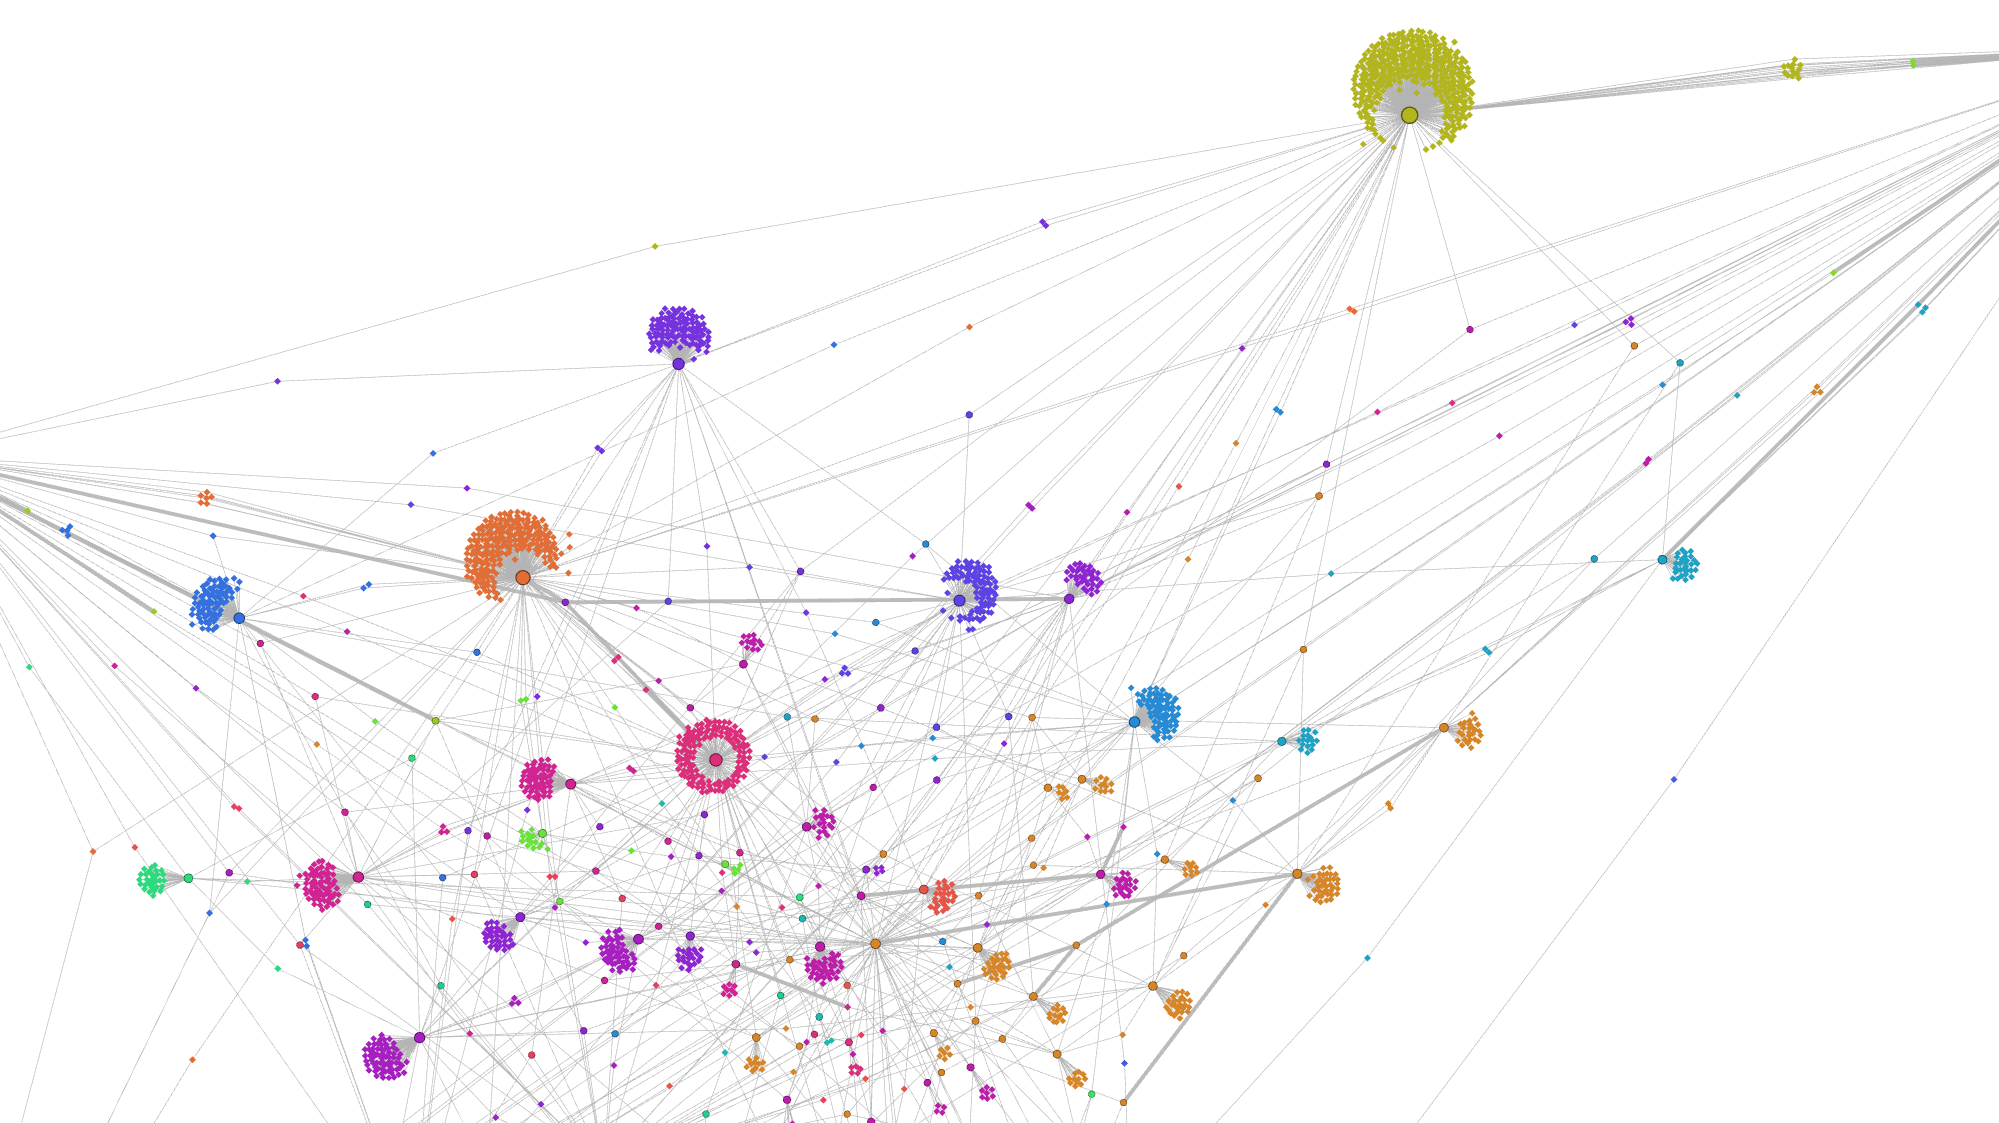

Core:

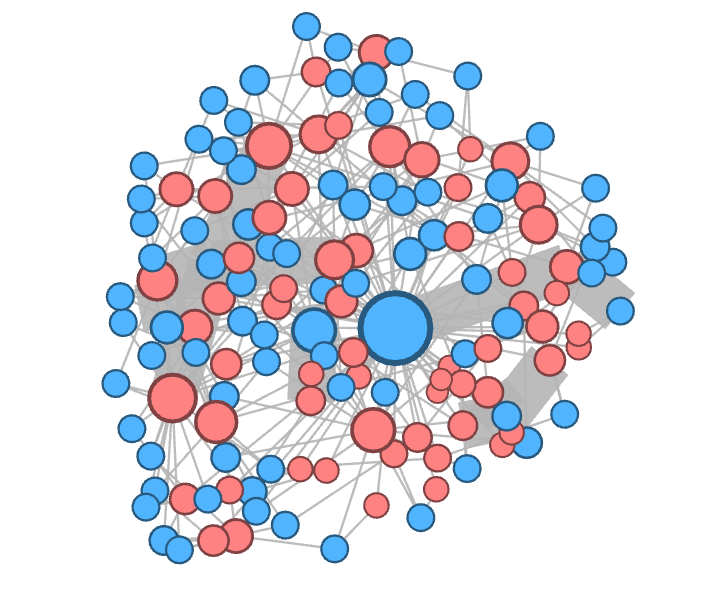

TopK posts:

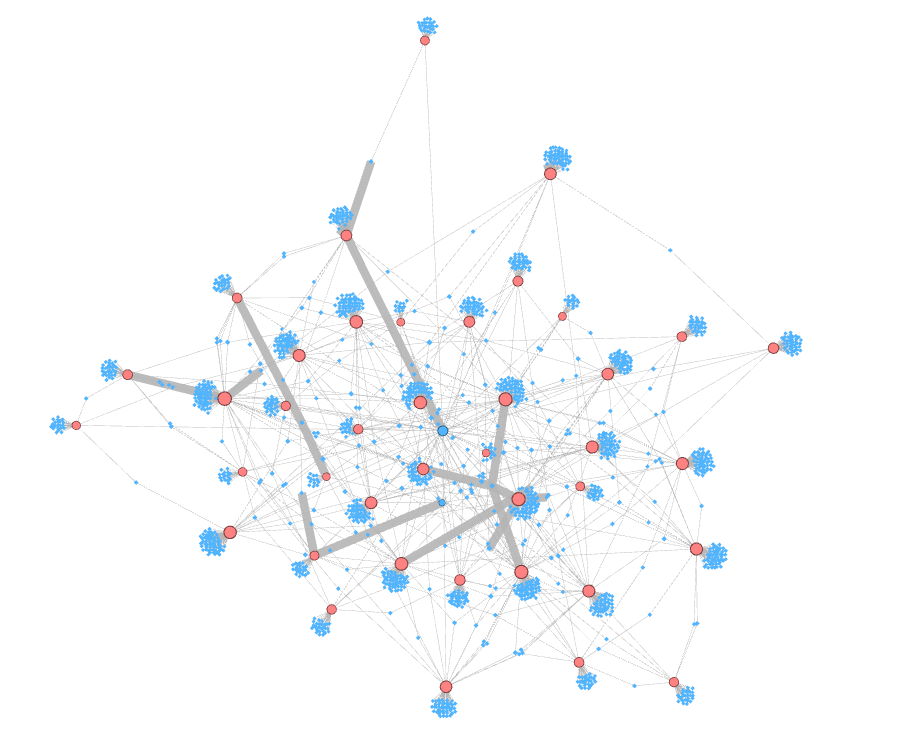

User Sample:

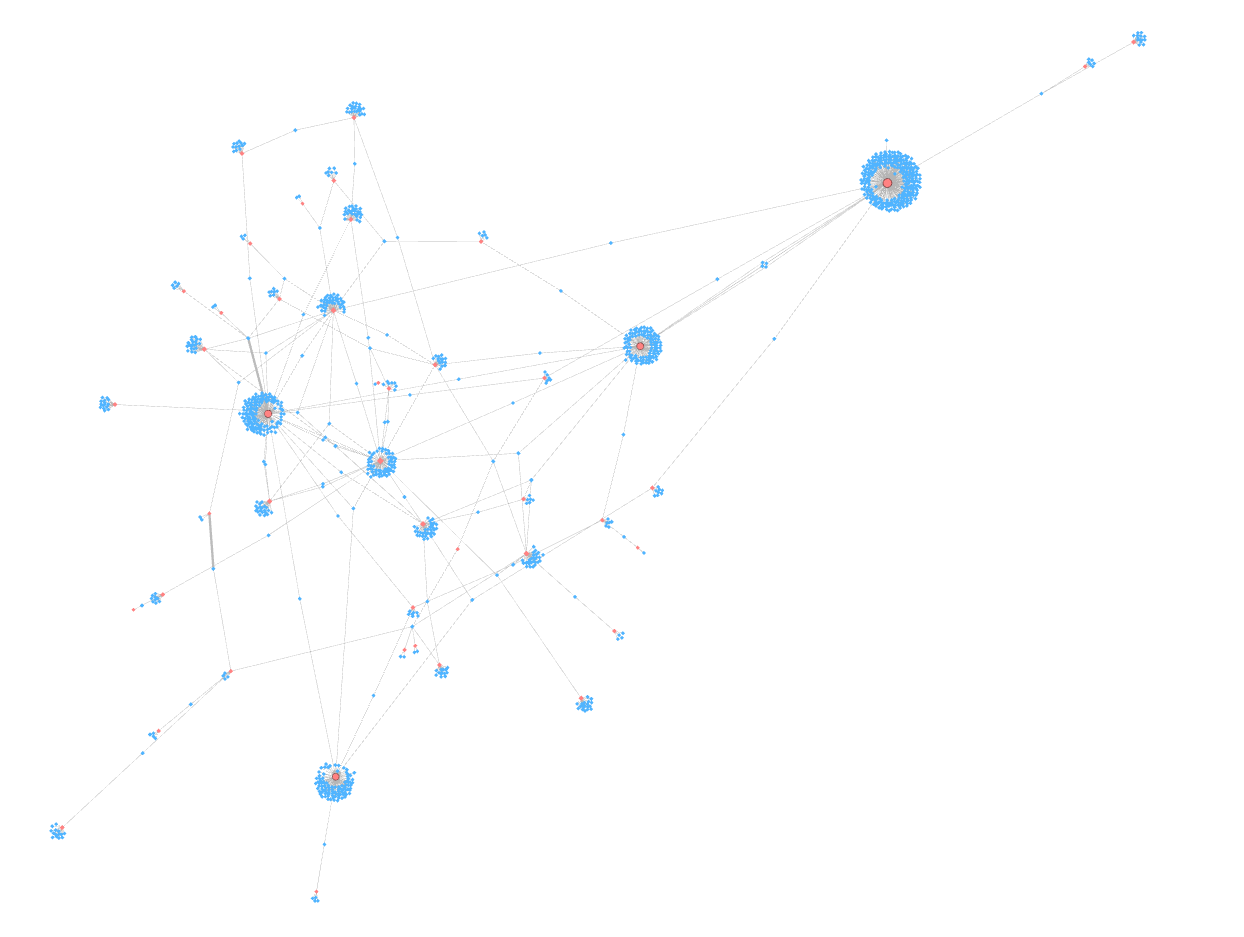

### **Centrality snapshot for the comments network**

This table is a **leaderboard of structural importance** in the post–user comment graph.  
Each row is a vertex (`name`), its `type` (here: **posts**), and four centrality scores that capture
**different kinds of prominence** in the interaction structure.

**Columns (intuition)**
- **degree** — raw connectivity: how many distinct counterparts the node touches.  
  In this context: how many **unique users** commented on a post (or posts a user commented on).
- **betweenness** — brokerage: how often a node lies on **shortest paths** between others, i.e., how much it can
  **bridge otherwise separate groups**. High values signal **cross-audience reach**.
- **closeness** — reachability: inverse of the average distance to everyone else.  
  Higher means the node is **near the center** of the network and can “reach” others quickly.
- **eigenvector** — prestige via important neighbors: a node scores high if it’s linked to **other well-connected nodes**.
  It’s normalized so that the **top item = 1.0**.

In [119]:
def centralities_df(G: ig.Graph, use_weights=True) -> pd.DataFrame:
    w = G.es["weight"] if (use_weights and "weight" in G.es.attributes()) else None
    deg = np.array(G.degree())                              # undirected degree
    bet = np.array(G.betweenness(weights=w))                # can be slow on very large graphs
    # For closeness on disconnected graphs, use mode="all" and igraph’s normalization:
    clos = np.array(G.closeness(weights=w))                 # igraph handles undirected by default
    eig  = np.array(G.eigenvector_centrality(weights=w))    # power method; may warn on tiny comps

    df = pd.DataFrame({
        "name": G.vs["name"],
        "type": np.where(G.vs["type"], "user", "post"),
        "degree": deg,
        "betweenness": bet,
        "closeness": clos,
        "eigenvector": eig,
    })
    return df

cent_comm = centralities_df(G_full)

# Peek similar to R's "sort by type then by degree (desc)"
display(cent_comm.sort_values(["type", "degree"], ascending=[True, False]).head(20))

#cent_comm.to_csv(OUT / "centralities_comments.csv", index=False)

,name,type,degree,betweenness,closeness,eigenvector
61,35245929077_10157765156480183,post,1052,4.130392e+06,0.394938,1.000000
45,35245929077_10154867577784078,post,518,2.116143e+06,0.360254,0.002437
49,35245929077_10154857779854078,post,437,1.801664e+06,0.356857,0.033189
5,35245929077_10154961407259078,post,376,1.578456e+06,0.352398,0.004691
43,35245929077_10154873127869078,post,275,1.115546e+06,0.347996,0.005326
17,35245929077_10154939818689078,post,177,6.883785e+05,0.341814,0.003659
27,35245929077_10154922389119078,post,160,6.381893e+05,0.340942,0.002433
40,35245929077_935674379898114,post,124,5.046202e+05,0.339134,0.001355
51,35245929077_10154851956794078,post,114,4.483209e+05,0.339616,0.003423
0,35245929077_10154976061679078,post,103,4.130213e+05,0.339058,0.001219


**How to read the sample output**

- The first row (`…10157765156480183`) is a **standout hub**:
  - `degree = 1052` → ~1k distinct commenters: **exceptionally broad engagement**.
  - `betweenness ≈ 4.1e6` → heavily traversed in shortest paths: **audience-bridging** post.
  - `closeness ≈ 0.395` → **centrally placed**, short paths to the rest of the graph.
  - `eigenvector = 1.0` → by normalization, this post anchors the **most prestigious neighborhood**.

- Subsequent posts show a **gradient of influence**:
  - Degrees step down (518, 437, 376, …) indicating fewer unique commenters.
  - Betweenness drops accordingly, reflecting **less brokerage** across user groups.
  - Closeness values cluster around **0.34–0.36**: these posts are still **near the core** of the conversation.
  - Eigenvector values vary (e.g., 0.033, 0.004, …): even with decent degree, some posts connect to **less influential neighborhoods**, so their prestige score is **modest**.

- The list shows **posts only** because the preview was **sorted by `type` then by degree (descending)**,
  so post hubs appear before user hubs.

**Why this is useful**
- **Editorial/Content insights:** identify posts that are not only popular (high degree) but also **structurally pivotal** (high betweenness).
- **Seeding/Amplification:** posts with high eigenvector connect to **influential audiences**; they’re good anchors for further engagement.
- **Moderation/Community mapping:** high betweenness items often sit between **distinct clusters** and can reveal cross-topic bridges.


##### 1) Degree distribution (log–log), split by type

Shows how engagement spreads for posts vs users.

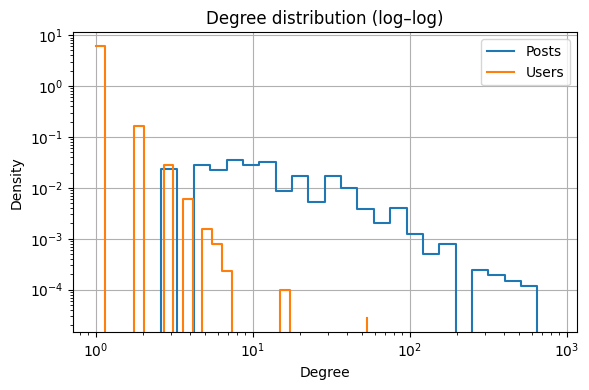

In [120]:
fig = plt.figure(figsize=(6,4))
for t, label in [("post", "Posts"), ("user", "Users")]:
    d = cent_comm.loc[cent_comm["type"]==t, "degree"].values
    d = d[d>0]
    bins = np.logspace(np.log10(1), np.log10(max(d)), 30)
    counts, edges = np.histogram(d, bins=bins, density=True)
    plt.step(edges[:-1], counts, where="post", label=label)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree"); plt.ylabel("Density"); plt.legend(); plt.title("Degree distribution (log–log)")
plt.tight_layout()


The blue curve (posts) spans several orders of magnitude — a few posts gather hundreds of commenters, while most get very few.  
The orange curve (users) drops sharply, meaning most users comment only once or twice.  
→ Classic **heavy-tailed engagement pattern**, where a small number of posts drive most interactions.


##### 2) Betweenness vs Degree (log axes) with labels for top hubs

Great for spotting posts that are both popular and brokerage-heavy.

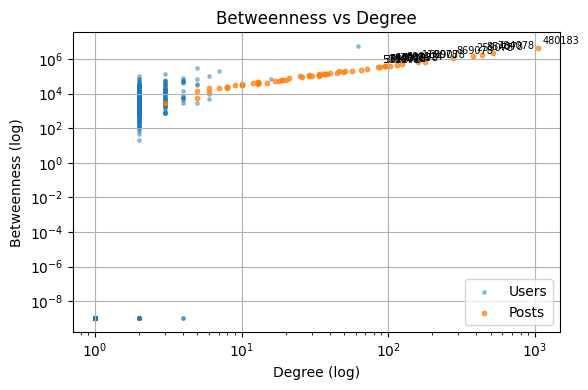

In [121]:
df = cent_comm.copy()
is_post = df["type"].eq("post").values
deg = df["degree"].values
bet = df["betweenness"].values

fig = plt.figure(figsize=(6,4))
plt.scatter(deg[~is_post]+1e-9, bet[~is_post]+1e-9, s=6, alpha=0.4, label="Users")
plt.scatter(deg[ is_post]+1e-9, bet[ is_post]+1e-9, s=10, alpha=0.7, label="Posts")

# label top 15 by betweenness (posts only)
top_idx = np.argsort(-(bet + (1-is_post)*-1e99))[:15]
for i in top_idx:
    if is_post[i]:
        plt.annotate(str(df["name"].iloc[i])[-6:], (deg[i], bet[i]), fontsize=7, xytext=(3,3), textcoords="offset points")

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree (log)"); plt.ylabel("Betweenness (log)")
plt.title("Betweenness vs Degree")
plt.legend(); plt.tight_layout()

Posts (orange) climb diagonally — higher degree strongly correlates with high betweenness.  
This means that the most commented posts also serve as **bridges between user groups**.  
Users (blue) cluster at the bottom left, showing limited cross-group influence.

##### 3) Eigenvector vs Closeness, colored by type

Separates “prestige via neighbors” from “centrality in reach”.

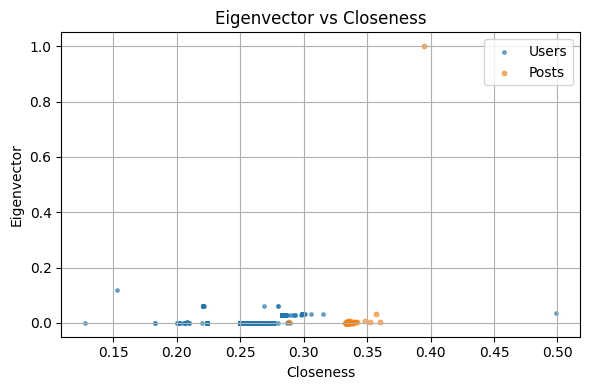

In [122]:
fig = plt.figure(figsize=(6,4))
for t, label, ms in [("user","Users",6), ("post","Posts",10)]:
    dft = cent_comm[cent_comm["type"]==t]
    plt.scatter(dft["closeness"], dft["eigenvector"], s=ms, alpha=0.6, label=label)
plt.xlabel("Closeness"); plt.ylabel("Eigenvector")
plt.title("Eigenvector vs Closeness")
plt.legend(); plt.tight_layout()

Highlights how “prestige” (importance of neighbors) relates to “reach” (average distance).  
Only a few posts stand out with both high closeness and eigenvector values, acting as **core influencers** in the discussion.  
Most other nodes lie near zero — peripheral and locally engaged.

##### 4) Top-20 posts by degree (horizontal bars)

Quick “leaderboard” of the most commented posts.

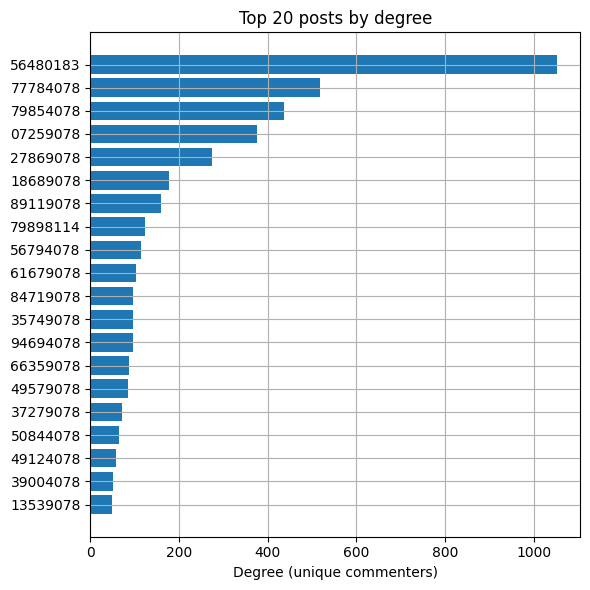

In [123]:
topk = (cent_comm[cent_comm["type"]=="post"]
        .nlargest(20, "degree")
        .loc[:, ["name","degree"]])
labels = [str(x)[-8:] for x in topk["name"]]  # short suffix labels

fig = plt.figure(figsize=(6,6))
plt.barh(range(len(topk)), topk["degree"].values)
plt.yticks(range(len(topk)), labels)
plt.gca().invert_yaxis()
plt.xlabel("Degree (unique commenters)")
plt.title("Top 20 posts by degree")
plt.tight_layout()


The top post (ending in *80183*) far surpasses others, confirming its dominance seen in the centrality scores.  
Beyond the first few, degrees fall rapidly, reinforcing a **strong popularity skew**.

##### 5) Centrality correlations (simple heatmap)

See which metrics move together.

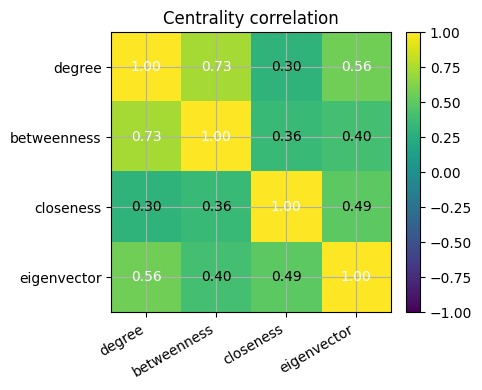

In [124]:
C = cent_comm[["degree","betweenness","closeness","eigenvector"]].corr().values
labels = ["degree","betweenness","closeness","eigenvector"]
# In the plot add the value as number in each cell
fig = plt.figure(figsize=(5,4))
im = plt.imshow(C, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)
plt.title("Centrality correlation")
plt.tight_layout()
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        plt.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center", color="w" if abs(C[i,j])>0.5 else "black")

- **Degree ↔ Betweenness (0.73):** strongly aligned — popularity and brokerage coincide.  
- **Degree ↔ Eigenvector (0.56):** moderately correlated — popular nodes tend to be prestigious too.  
- **Closeness** is only weakly tied to others, showing it captures a **different notion of centrality** (distance-based rather than volume-based).  
Overall, the heatmap confirms that **in this network, engagement (degree) largely drives influence**.

### **Centrality Distributions – Comments Network (Log–Log Scale)**

In [125]:
def loglog_density(x, title):
    x = np.asarray(x, float)
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        print(f"[warn] nothing positive/finite to plot for {title}")
        return
    plt.figure()
    # Histogram as a proxy for density (more stable than KDE for heavy tails)
    plt.hist(x, bins=100, density=True)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel(title); plt.ylabel("Density")
    plt.title(f"Log–log density of {title}")
    plt.grid(True)

    plt.show()

##### **1️⃣ Betweenness Centrality**

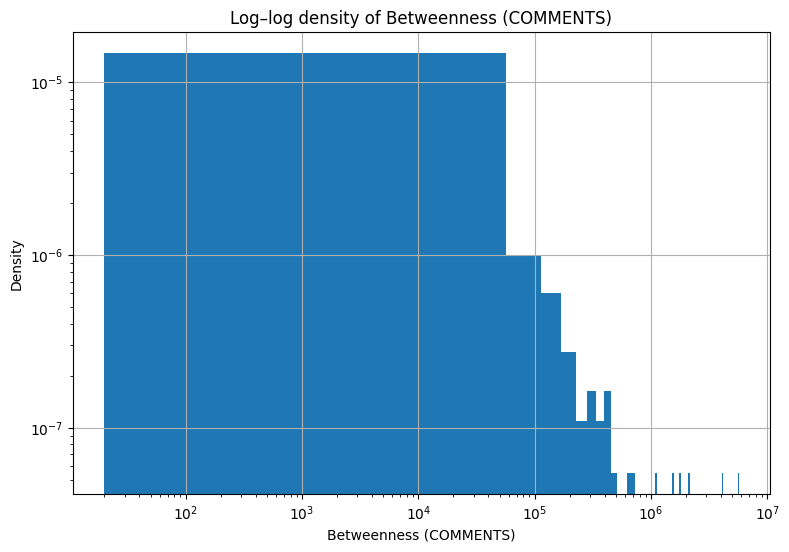

In [126]:
loglog_density(cent_comm["betweenness"], "Betweenness (COMMENTS)")

The distribution shows a **steep, heavy-tailed pattern**, with most nodes concentrated at very low betweenness values and only a handful reaching extremely high levels (up to 10⁶–10⁷).  
This imbalance means that **very few posts or users act as critical bridges** connecting otherwise separate parts of the discussion.  
Most nodes play purely local roles — participating but not structuring the flow of conversation.

→ **Interpretation:** information or attention in the network likely funnels through a small number of “bridge” posts that connect diverse audiences.

##### **2️⃣ Closeness Centrality**


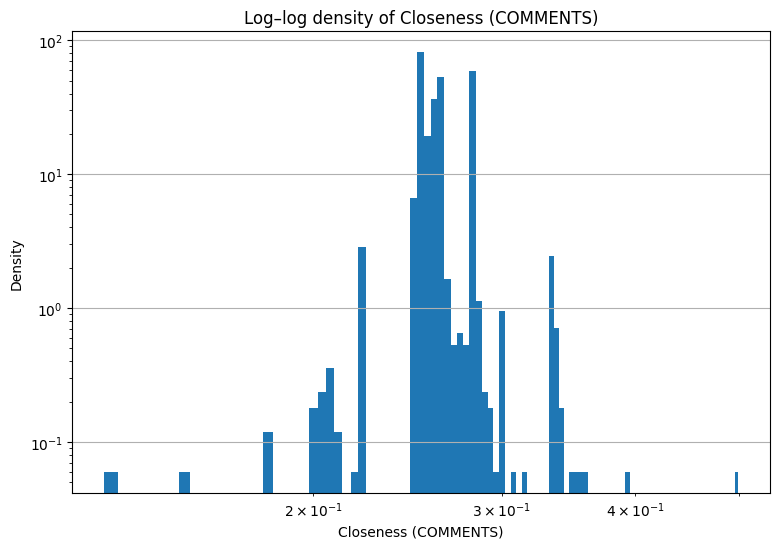

In [127]:
loglog_density(cent_comm["closeness"],   "Closeness (COMMENTS)")

The closeness values are much more **clustered** and symmetric, mostly between 0.2 and 0.35.  
This indicates that, although the network is large, most nodes sit within a **similar distance** from others — there are no isolated islands.  
The peaks around 0.28–0.30 suggest a common “reach depth” for the majority of users and posts.

→ **Interpretation:** communication paths are fairly compact; participants are generally just a few steps away from one another.

##### **3️⃣ Eigenvector Centrality**


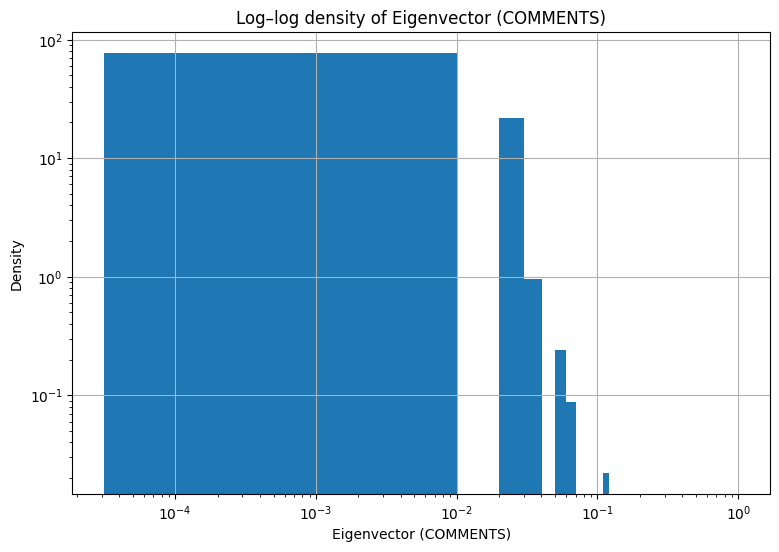

In [128]:
loglog_density(cent_comm["eigenvector"], "Eigenvector (COMMENTS)")

Here again, we see a **strong skew**: almost all nodes have tiny eigenvector scores (<10⁻²), while a few reach much higher values.  
Only a **select handful of posts** (and perhaps some connected users) are influential through their association with other influential nodes.  
This highlights a **hierarchical structure**, where prestige and connectivity reinforce one another.

→ **Interpretation:** network influence is highly centralized — a few key posts dominate the overall prestige landscape, while most remain peripheral.

### **Degree Distribution with Power-Law Fit**

This plot tests whether the degree distribution — the number of connections per node — follows a **power-law**, which is common in social and information networks.

The **blue curve** shows the empirical probability density of degrees (on a log–log scale).  
The **orange line** represents the best-fitting power-law model.

[COMMENTS degree] alpha=1.998, xmin=29.0,  KS=0.091


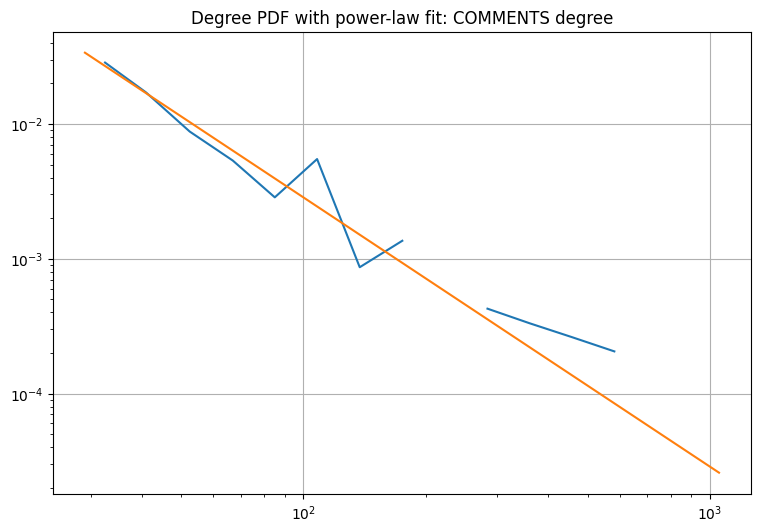

In [129]:
import powerlaw

def powerlaw_quick_report(degrees, title):
    d = np.asarray(degrees, float)
    d = d[np.isfinite(d) & (d > 0)]
    fit = powerlaw.Fit(d, discrete=True, verbose=False)
    print(f"[{title}] alpha={fit.alpha:.3f}, xmin={fit.xmin},  KS={fit.D:.3f}")
    # visual:
    fit.plot_pdf()
    fit.power_law.plot_pdf()
    plt.title(f"Degree PDF with power-law fit: {title}")
    plt.show()

powerlaw_quick_report(cent_comm["degree"], "COMMENTS degree")

**Fit summary**
- **α (alpha) = 1.998** — the *scaling exponent*, describing how quickly probabilities drop for large degrees.  
  A value near **2** indicates a **heavy-tailed** distribution: most nodes have few links, while a few hubs have extremely many.
- **x_min = 29** — the lower cutoff where the power-law behavior starts; below this, degree values don’t fit the model well.
- **KS (Kolmogorov–Smirnov) = 0.091** — goodness-of-fit statistic; the lower it is, the better the model alignment (values <0.1 are generally acceptable).

---

**Interpretation**
The network exhibits **scale-free behavior**: connectivity is highly unequal, with a small elite of posts or users receiving a disproportionate share of attention.  
This structure implies:
- **Robustness** to random loss (most nodes are peripheral).  
- **Vulnerability** to targeted removal of hubs (network cohesion depends on few key posts/users).  
- **Preferential attachment dynamics** — popular nodes attract more connections over time.

In short: the comments network behaves like a **self-organizing social system**, where engagement naturally concentrates around a few central hubs.

In [130]:
# --- PROJECTIONS (posts/users) with Gephi export, using your helper ---

from scipy import sparse
import numpy as np
import igraph as ig

def build_incidence_from_bipartite(
    G: ig.Graph,
    post_labels: np.ndarray,
    user_labels: np.ndarray,
    use_weights: bool = False,
):
    """
    Returns a CSR incidence matrix A of shape (n_posts, n_users)
    rows = posts (in the same order as `post_labels`)
    cols = users (in the same order as `user_labels`)
    Values are 1 (binary) or edge weights if use_weights=True.
    """
    n_posts = len(post_labels)
    n_users = len(user_labels)

    post_idx, user_idx, vals = [], [], []
    weights = G.es["weight"] if ("weight" in G.es.attributes()) else [1.0] * G.ecount()

    for (u, v), w in zip(G.get_edgelist(), weights):
        # ensure (post, user) ordering
        if u < n_posts and v >= n_posts:
            p, q = u, v - n_posts
        elif v < n_posts and u >= n_posts:
            p, q = v, u - n_posts
        else:
            continue  # should not happen in a well-formed bipartite
        post_idx.append(p)
        user_idx.append(q)
        vals.append(float(w) if use_weights else 1.0)

    A = sparse.coo_matrix((vals, (post_idx, user_idx)), shape=(n_posts, n_users)).tocsr()
    A.eliminate_zeros()
    return A


def projection_graph_from_affinity(M: sparse.spmatrix, names: list[str], role_label: str):
    """
    M is symmetric affinity (posts×posts or users×users), weighted.
    Builds an undirected igraph with edge weight = M[i,j].
    """
    M = M.tocsr(copy=True)
    M.setdiag(0)
    M.eliminate_zeros()
    M_ut = sparse.triu(M, k=1).tocoo()

    g = ig.Graph(
        n=M.shape[0],
        edges=list(zip(M_ut.row.tolist(), M_ut.col.tolist())),
        directed=False
    )
    g.es["weight"] = [float(w) for w in M_ut.data.tolist()] if g.ecount() > 0 else []
    g.vs["name"] = list(map(str, names))
    g.vs["role"] = role_label
    g.vs["type"] = [True if role_label == "user" else False] * g.vcount()
    return g


def project_and_export(
    G_bip: ig.Graph,
    post_labels: np.ndarray,
    user_labels: np.ndarray,
    tag: str,
    use_weights: bool = False,
):
    """
    Creates post–post and user–user projections and exports to GEXF.
    Returns both projection graphs: (g_posts, g_users).
    """
    A = build_incidence_from_bipartite(G_bip, post_labels, user_labels, use_weights=use_weights)

    # Projections
    P = (A @ A.T).tocsr()  # posts co-commented/liked by same users
    U = (A.T @ A).tocsr()  # users co-commented/liked same posts

    # Convert to igraph
    g_posts = projection_graph_from_affinity(P, post_labels.tolist(), role_label="post")
    g_users = projection_graph_from_affinity(U, user_labels.tolist(), role_label="user")

    # Export to Gephi-ready files
    export_gephi_autolayout_gexf(g_posts, OUT / f"03_post_projection_{tag}.gexf", use_communities=True)
    export_gephi_autolayout_gexf(g_users, OUT / f"03_user_projection_{tag}.gexf", use_communities=True)

    # Console summary
    print(f"[{tag.upper()} → POSTS] V={g_posts.vcount():,} E={g_posts.ecount():,}")
    print(f"[{tag.upper()} → USERS] V={g_users.vcount():,} E={g_users.ecount():,}")

    # ✅ Return graphs for further analysis
    return g_posts, g_users


# ---------- Run on COMMENTS (default binary projection to match R) ----------
g_post_c, g_user_c = project_and_export(G_full, post_labels, user_labels, tag="comments", use_weights=False)

# ---------- (optional) multiplicity-aware version ----------
# g_post_cw, g_user_cw = project_and_export(G_full, post_labels, user_labels, tag="comments_w", use_weights=True)

# users is heavier so it takes a while

✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\03_post_projection_comments.gexf
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\03_user_projection_comments.gexf
[COMMENTS → POSTS] V=62 E=1,891
[COMMENTS → USERS] V=4,480 E=977,823


Post proj:

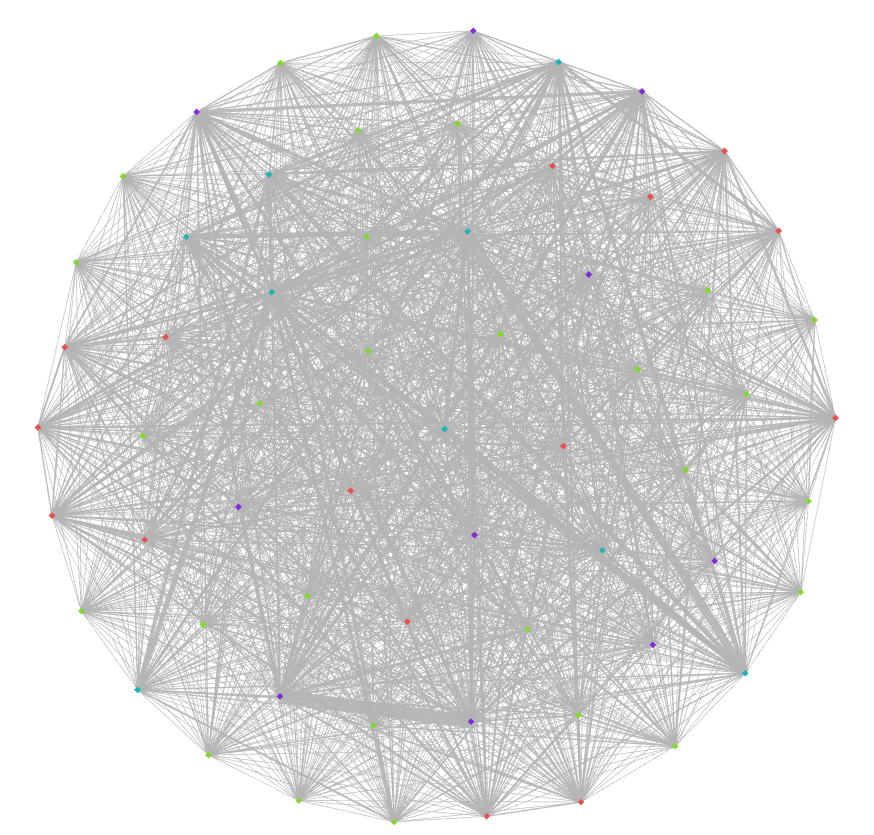

User proj:

Also too heavy

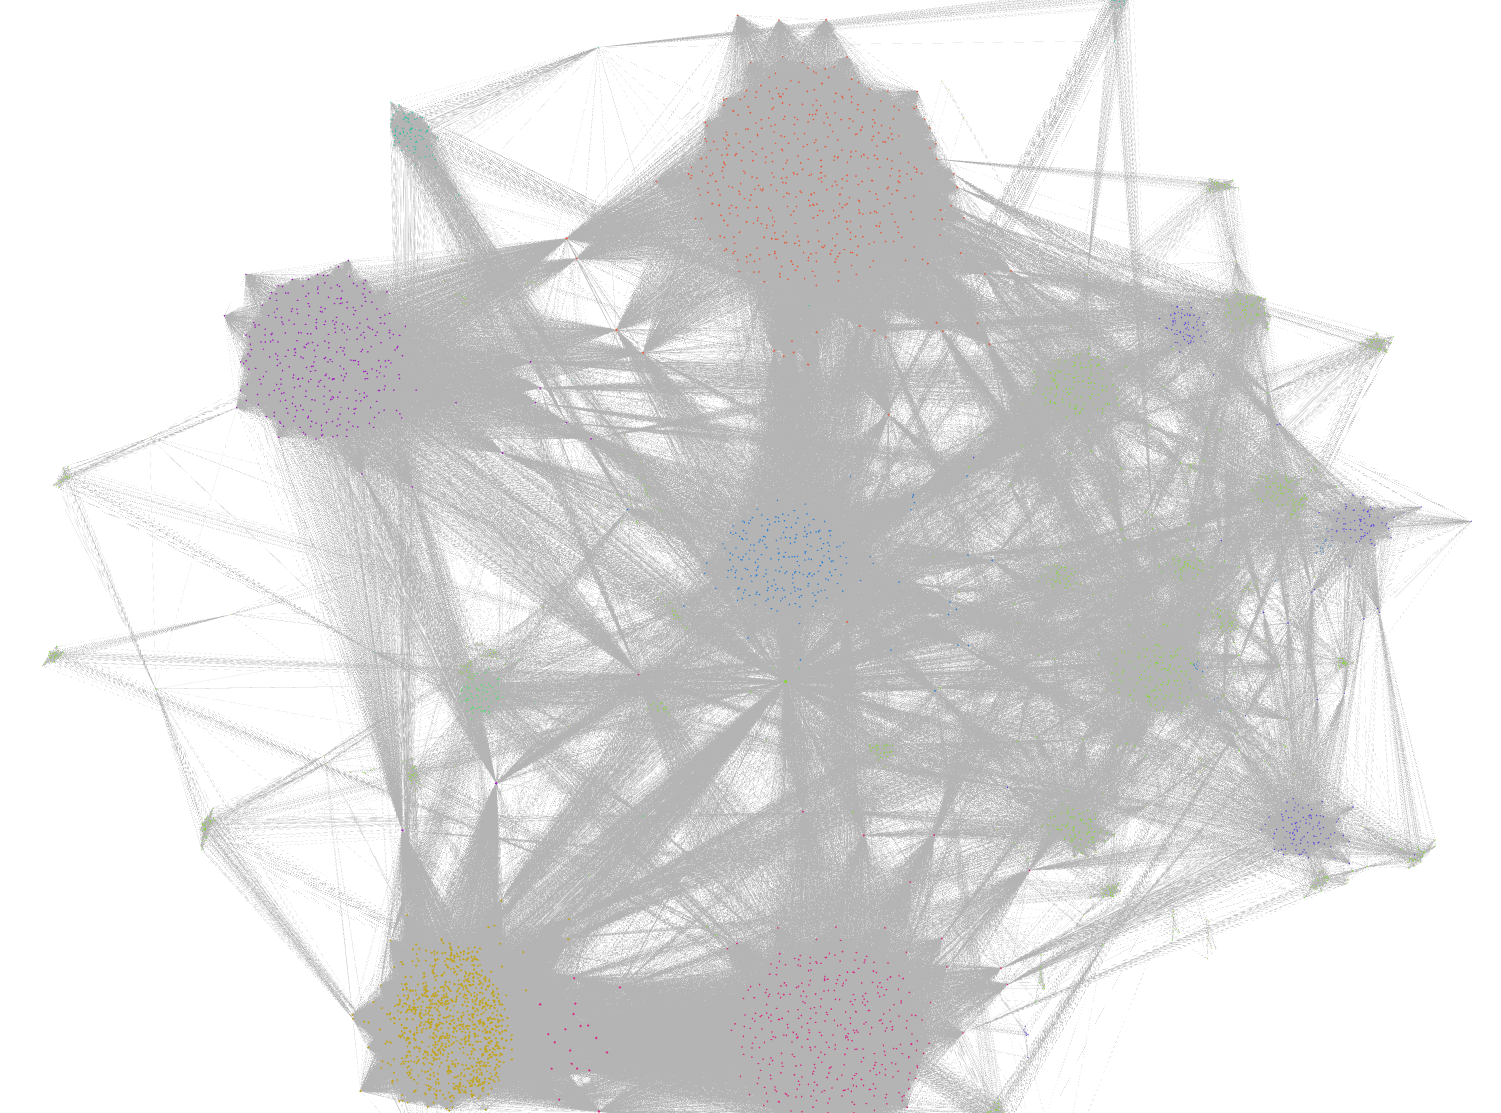

Binary overlap turned the post network into a **complete graph** — every post was linked to every other by a single shared commenter.

In [131]:
def safe_powerlaw_fit(x, discrete=True, label=""):
    """Fit power law only if there is enough variability."""
    import powerlaw
    x = np.asarray(x, float)
    x = x[np.isfinite(x) & (x > 0)]
    uniq = np.unique(x).size
    if uniq < 3:
        print(f"[{label}] too few unique values ({uniq}) → skip fit")
        return None
    fit = powerlaw.Fit(x, discrete=discrete, verbose=False)
    print(f"[{label}] alpha={fit.alpha:.3f}, xmin={fit.xmin}, KS={fit.D:.3f}")
    return fit

In [132]:
# Degrees & density in the POST projection
deg = np.array(g_post_c.degree())
# Attempt power-law on projection degrees (expected to skip if constant)
_ = safe_powerlaw_fit(deg, discrete=True, label="post projection degree")

[post projection degree] too few unique values (1) → skip fit


<!-- ### Sanity Check -->

In [133]:
print("unique degrees:", np.unique(deg)[:10], " … total uniques =", np.unique(deg).size)
print("min/max/mean degree:", deg.min(), deg.max(), deg.mean())

V, E = g_post_c.vcount(), g_post_c.ecount()
density = 2*E / (V*(V-1) + 1e-9)
print(f"V={V} E={E}  density≈{density:.6f}")

unique degrees: [61]  … total uniques = 1
min/max/mean degree: 61 61 61.0
V=62 E=1891  density≈1.000000


that’s a complete graph

In [134]:
# Rebuild the binary incidence and count zero overlaps off-diagonal
A = build_incidence_from_bipartite(G_full, post_labels, user_labels, use_weights=False)
A_bin = A.copy(); A_bin.data[:] = 1.0

P = (A_bin @ A_bin.T).tocsr()   # post×post intersections
P.setdiag(0); P.eliminate_zeros()

n_posts = P.shape[0]
num_pairs = n_posts*(n_posts-1)//2
num_nonzero_pairs = P.count_nonzero()  # counts both triangles; use upper-tri for exact undirected pairs:
num_nonzero_pairs_ut = sparse.triu(P, 1).count_nonzero()

print("Undirected post pairs:", num_pairs)
print("Pairs with overlap ≥1:", num_nonzero_pairs_ut)
print("Share of overlapping pairs:", num_nonzero_pairs_ut / num_pairs)

Undirected post pairs: 1891
Pairs with overlap ≥1: 1891
Share of overlapping pairs: 1.0


almost every pair of posts shares at least one commenter, so binary projection produces edges everywhere.

In [135]:
# Inspect weight distribution in post projection
w = np.array(g_post_c.es["weight"]) if "weight" in g_post_c.es.attributes() else np.ones(g_post_c.ecount())
print("w min/mean/95%-ile/max:", w.min(), w.mean(), np.percentile(w,95), w.max())
print("fraction of edges with weight=1:", (w==1).mean())

w min/mean/95%-ile/max: 1.0 1.3595980962453729 3.0 20.0
fraction of edges with weight=1: 0.7572712850343734


the clique is real, but only a thin set of strong ties exists

In [136]:
V_u, E_u = g_user_c.vcount(), g_user_c.ecount()
density_u = 2*E_u / (V_u*(V_u-1) + 1e-9)
print(f"[users] V={V_u} E={E_u} density≈{density_u:.6f}")

[users] V=4480 E=977823 density≈0.097461


popular posts induce massive user cliques, so the user projection is very dense.

# From Bipartite Network to Meaningful Projections

This pipeline transforms a **bipartite social network** (posts ↔ users) into **interpretable projections** (post–post and user–user).  
In the original setup, a binary overlap made every post connected to every other — a **dense clique** where all degrees were equal and no structure was visible.

This new version introduces **controlled, meaningful projections** that:
- Capture *who shares audiences with whom*,
- Preserve only *strong or specific* connections,
- Automatically export **Gephi-ready graphs** with layout, sizes, and community colors.

### **1. Building the Incidence Matrix**

Convert the bipartite graph into a sparse matrix form:  
rows represent **posts**, columns represent **users**, and each cell shows whether the user interacted with that post.

In [137]:
from typing import Tuple, Literal, Optional

# ---------------------------------------------------------------------
# 1) Build incidence (posts × users), preserving label order
# ---------------------------------------------------------------------
def build_incidence_from_bipartite(
    G: ig.Graph,
    post_labels: np.ndarray,
    user_labels: np.ndarray,
    use_weights: bool = False,
) -> sparse.csr_matrix:
    """
    Return a CSR incidence matrix A of shape (n_posts, n_users).
    Rows = posts in the same order as `post_labels`.
    Cols = users in the same order as `user_labels`.
    Values are 1 (binary) or edge weights if use_weights=True.
    """
    n_posts = len(post_labels)
    n_users = len(user_labels)

    post_idx, user_idx, vals = [], [], []
    weights = G.es["weight"] if ("weight" in G.es.attributes()) else [1.0] * G.ecount()

    for (u, v), w in zip(G.get_edgelist(), weights):
        # enforce (post, user) orientation using the known split at n_posts
        if u < n_posts and v >= n_posts:
            p, q = u, v - n_posts
        elif v < n_posts and u >= n_posts:
            p, q = v, u - n_posts
        else:
            continue  # should not happen if G is truly bipartite (posts first, users next)
        post_idx.append(p)
        user_idx.append(q)
        vals.append(float(w) if use_weights else 1.0)

    A = sparse.coo_matrix((vals, (post_idx, user_idx)), shape=(n_posts, n_users)).tocsr()
    A.eliminate_zeros()
    return A


### **2. Choosing the Similarity Measure**

Define what “similarity” means for two posts or two users. It quantifies *how much two entities share audiences*, discounting trivial overlaps

| Mode | Description | When to Use |
|------|--------------|-------------|
| **count** | Simple overlaps (`A·Aᵀ`) | Fast but causes cliques (too dense) |
| **cosine** | Normalized co-audience similarity | Best default; balances degree differences |
| **jaccard** | Intersection ÷ Union | Conservative; good with highly uneven activity |
| **tfidf_cosine** | Cosine after TF–IDF reweighting | Downweights ubiquitous users or posts |


In [138]:
# ---------------------------------------------------------------------
# 2) Normalizations / similarities on the incidence
# ---------------------------------------------------------------------
def _row_l2_normalize(X: sparse.csr_matrix) -> sparse.csr_matrix:
    """Row-wise L2 normalization for CSR."""
    X = X.tocsr(copy=True)
    norms = np.sqrt(X.multiply(X).sum(axis=1)).A1
    norms[norms == 0] = 1.0
    X.data /= norms.repeat(np.diff(X.indptr))
    return X

def _binary_copy(A: sparse.csr_matrix) -> sparse.csr_matrix:
    """Binary version of A (copy)."""
    B = A.copy().tocsr()
    B.data[:] = 1.0
    return B

def tfidf_rows(A: sparse.csr_matrix) -> sparse.csr_matrix:
    """
    Row-wise TF-IDF weighting for posts×users incidence.
    - TF: counts per row (as-is)
    - IDF: log((1 + n_rows) / (1 + df)) + 1, where df = #rows where user appears
    """
    A = A.tocsr(copy=True)
    n_rows = A.shape[0]
    df = np.asarray((A > 0).sum(axis=0)).ravel()  # per user
    idf = np.log((1 + n_rows) / (1 + df)) + 1.0
    # scale each nonzero by the column's IDF
    A = A.tocoo()
    A.data = A.data * idf[A.col]
    return A.tocsr()

def project_similarity(
    A: sparse.csr_matrix,
    mode: Literal["count", "cosine", "jaccard", "tfidf_cosine"] = "count",
) -> Tuple[sparse.csr_matrix, sparse.csr_matrix]:
    """
    Build post–post (P) and user–user (U) similarity/affinity matrices from incidence A.

    mode:
      - "count":     P = A A^T,            U = A^T A        (raw overlaps, can be dense)
      - "cosine":    P = normalize(A) @ normalize(A)^T      (Salton cosine)
                     U = normalize(A.T) @ normalize(A.T)^T
      - "jaccard":   P_ij = |N(i)∩N(j)| / |N(i)∪N(j)|       (binary, degree-aware)
      - "tfidf_cosine": cosine after TF-IDF reweighting rows (downweights ubiquitous users)
    """
    if mode == "count":
        A_use = _binary_copy(A)
        P = (A_use @ A_use.T).tocsr()
        U = (A_use.T @ A_use).tocsr()
        return P, U

    if mode == "cosine":
        A_bin = _binary_copy(A)
        P = (_row_l2_normalize(A_bin) @ _row_l2_normalize(A_bin).T).tocsr()
        U = (_row_l2_normalize(A_bin.T) @ _row_l2_normalize(A_bin.T).T).tocsr()
        return P, U

    if mode == "tfidf_cosine":
        A_tfidf = tfidf_rows(A)                  # TF-IDF on rows (posts)
        P = (_row_l2_normalize(A_tfidf) @ _row_l2_normalize(A_tfidf).T).tocsr()
        # For users, apply TF-IDF on A^T (users as "rows")
        AT_tfidf = tfidf_rows(A.T)
        U = (_row_l2_normalize(AT_tfidf) @ _row_l2_normalize(AT_tfidf).T).tocsr()
        return P, U

    if mode == "jaccard":
        A_bin = _binary_copy(A)
        # intersections
        P_int = (A_bin @ A_bin.T).tocsr()
        U_int = (A_bin.T @ A_bin).tocsr()
        # degrees
        deg_p = np.asarray(A_bin.sum(axis=1)).ravel()
        deg_u = np.asarray(A_bin.sum(axis=0)).ravel()

        # convert intersections to Jaccard by dividing by union
        def _to_jaccard(INT: sparse.csr_matrix, deg_vec: np.ndarray) -> sparse.csr_matrix:
            M = INT.tolil(copy=True)
            rows, data = M.rows, M.data
            for i in range(M.shape[0]):
                di = deg_vec[i]
                for k in range(len(rows[i])):
                    j = rows[i][k]
                    inter = data[i][k]
                    uni = di + deg_vec[j] - inter
                    data[i][k] = inter / (uni if uni > 0 else 1.0)
            return M.tocsr()

        return _to_jaccard(P_int, deg_p), _to_jaccard(U_int, deg_u)

    raise ValueError(f"Unknown mode: {mode}")


### **3. Sparsification: Keeping Only Meaningful Ties**

Projections can explode in size; this step filters weak or redundant edges.

**Techniques:**
- **Thresholding** → drop edges below a similarity cutoff (e.g., cosine < 0.05).  
  Removes weak overlaps.
- **Top-k per row** → for each node, keep only the *k strongest* links (then symmetrize).  
  Keeps the most relevant neighbors and prevents visual clutter.

In [139]:
# ---------------------------------------------------------------------
# 3) Build an igraph from a symmetric affinity matrix
# ---------------------------------------------------------------------
def projection_graph_from_affinity(
    M: sparse.spmatrix,
    names: list[str],
    role_label: Literal["post", "user"],
) -> ig.Graph:
    """
    M: symmetric affinity (CSR preferred). Adds edges (i,j) with weight=M[i,j], i<j.
    Node attributes: name, role, type (False=post, True=user).
    """
    M = M.tocsr(copy=True)
    M.setdiag(0); M.eliminate_zeros()
    M_ut = sparse.triu(M, k=1).tocoo()

    g = ig.Graph(
        n=M.shape[0],
        edges=list(zip(M_ut.row.tolist(), M_ut.col.tolist())),
        directed=False
    )
    w = [float(x) for x in M_ut.data.tolist()] if M_ut.nnz else []
    g.es["weight"] = w
    g.vs["name"] = list(map(str, names))
    g.vs["role"] = role_label
    g.vs["type"] = [True if role_label == "user" else False] * g.vcount()
    return g


### **4. Graph Construction from Similarity Matrices**

Turn symmetric similarity matrices into real `igraph` objects. This makes the network compatible with standard graph analytics and community detection tools.

Each graph:
- Is **undirected** (mutual similarity),
- Edges carry **weights**,
- Nodes include:
  - `name` → original ID  
  - `role` → `"post"` or `"user"`  
  - `type` → boolean (`False` for post, `True` for user`)



In [140]:
# ---------------------------------------------------------------------
# 4) Simple sparsifiers: threshold & per-row top-k
# ---------------------------------------------------------------------
def threshold_matrix(M: sparse.csr_matrix, min_w: float) -> sparse.csr_matrix:
    """Keep entries with value >= min_w."""
    M = M.tocsr(copy=True)
    M.data[M.data < min_w] = 0.0
    M.eliminate_zeros()
    return M

def topk_per_row(M: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    """
    Keep only the largest k values in each row (symmetric later via max).
    Useful to avoid dense hairballs.
    """
    M = M.tolil(copy=True)
    for i in range(M.shape[0]):
        dat = M.data[i]
        if len(dat) > k:
            idx = np.argpartition(dat, -k)[-k:]  # indices of top-k in this row
            keep = set(np.array(M.rows[i])[idx].tolist())
            new_rows, new_data = [], []
            for j, v in zip(M.rows[i], M.data[i]):
                if j in keep:
                    new_rows.append(j); new_data.append(v)
            M.rows[i], M.data[i] = new_rows, new_data
    # symmetrize by taking the maximum (keeps undirected consistency)
    M = M.tocsr()
    return M.maximum(M.T)


### **5. Exporting to Gephi (Auto Layout + Styling)**

Generate `.gexf` files ready for visualization in Gephi. So u can open the file directly in Gephi and instantly explore meaningful clusters, hubs, and engagement patterns.


**Automatically includes:**
- **Layout:** ForceAtlas2-like (or Fruchterman-Reingold fallback)
- **Nodes:**  
  - Size = degree  
  - Color = community (Leiden algorithm)  
  - Shape = square for posts, circle for users  
- **Edges:**  
  - Thickness = weight  


In [ ]:
# ---------------------------------------------------------------------
# 5) One-shot pipeline: build projections, sparsify, export to Gephi
# ---------------------------------------------------------------------
def project_and_export(
    G_bip: ig.Graph,
    post_labels: np.ndarray,
    user_labels: np.ndarray,
    tag: str,
    *,
    use_edge_weights: bool = False,                    # incidence uses weights if True
    similarity: Literal["count", "cosine", "jaccard", "tfidf_cosine"] = "cosine",
    topk_posts: Optional[int] = 15,                    # per-row keep k for posts projection (None to disable)
    topk_users: Optional[int] = 25,                    # per-row keep k for users projection (None to disable)
    min_w_posts: Optional[float] = None,               # threshold after similarity (None to skip)
    min_w_users: Optional[float] = None,
    export_posts: bool = True,
    export_users: bool = True,
) -> Tuple[ig.Graph, ig.Graph]:
    """
    Creates post–post and user–user projections with chosen similarity and sparsification,
    converts to igraph, and exports Gephi-ready GEXF files (using your helper).
    Returns (g_posts, g_users).
    """
    # 1) Incidence
    A = build_incidence_from_bipartite(G_bip, post_labels, user_labels, use_weights=use_edge_weights)

    # 2) Similarity / affinity
    P, U = project_similarity(A, mode=similarity)

    # 3) Sparsify (optional)
    if min_w_posts is not None:
        P = threshold_matrix(P, min_w_posts)
    if min_w_users is not None:
        U = threshold_matrix(U, min_w_users)
    if topk_posts is not None:
        P = topk_per_row(P, topk_posts)
    if topk_users is not None:
        U = topk_per_row(U, topk_users)

    # 4) To igraph
    g_posts = projection_graph_from_affinity(P, post_labels.tolist(), role_label="post")
    g_users = projection_graph_from_affinity(U, user_labels.tolist(), role_label="user")

    # 5) Export (Gephi-ready, color by communities)
    if export_posts:
        export_gephi_autolayout_gexf(g_posts, OUT / f"04_post_projection_{tag}.gexf", use_communities=True)
    if export_users:
        export_gephi_autolayout_gexf(g_users, OUT / f"04_user_projection_{tag}.gexf", use_communities=True)

    # 6) Console summary
    print(f"[{tag.upper()} → POSTS] V={g_posts.vcount():,} E={g_posts.ecount():,}")
    print(f"[{tag.upper()} → USERS] V={g_users.vcount():,} E={g_users.ecount():,}")

    return g_posts, g_users


In [142]:
# ---------------- Run on COMMENTS (recommended settings) ----------------
# Cosine + TF-IDF are good defaults when binary projection turns into a clique.
# Start with cosine + top-k, then tune thresholds if needed.

g_post_c, g_user_c = project_and_export(
    G_bip=G_full,
    post_labels=post_labels,
    user_labels=user_labels,
    tag="comments_cosine",
    use_edge_weights=False,     # keep the incidence binary to avoid popularity bias
    similarity="cosine",        # try "tfidf_cosine" if you want to downweight ubiquitous users
    topk_posts=15,              # keep top-15 neighbors per post
    topk_users=25,              # keep top-25 neighbors per user (users’ projection is much larger)
    min_w_posts=None,           # set e.g. 0.05 for cosine/Jaccard thresholds
    min_w_users=None,
    export_posts=True,
    export_users=True,
)


✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\03_post_projection_comments_cosine.gexf
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\03_user_projection_comments_cosine.gexf
[COMMENTS_COSINE → POSTS] V=62 E=705
[COMMENTS_COSINE → USERS] V=4,480 E=97,065


Post Proj cosine:

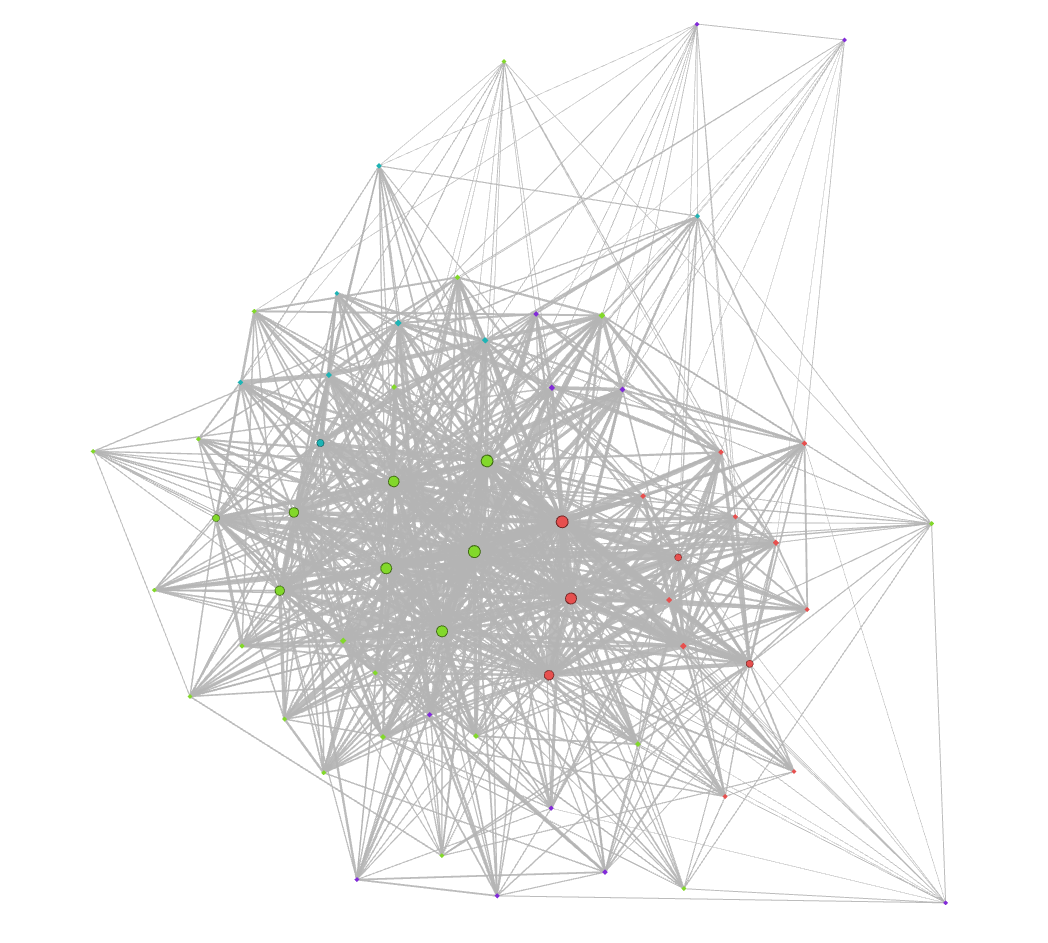

User Proj cosine:

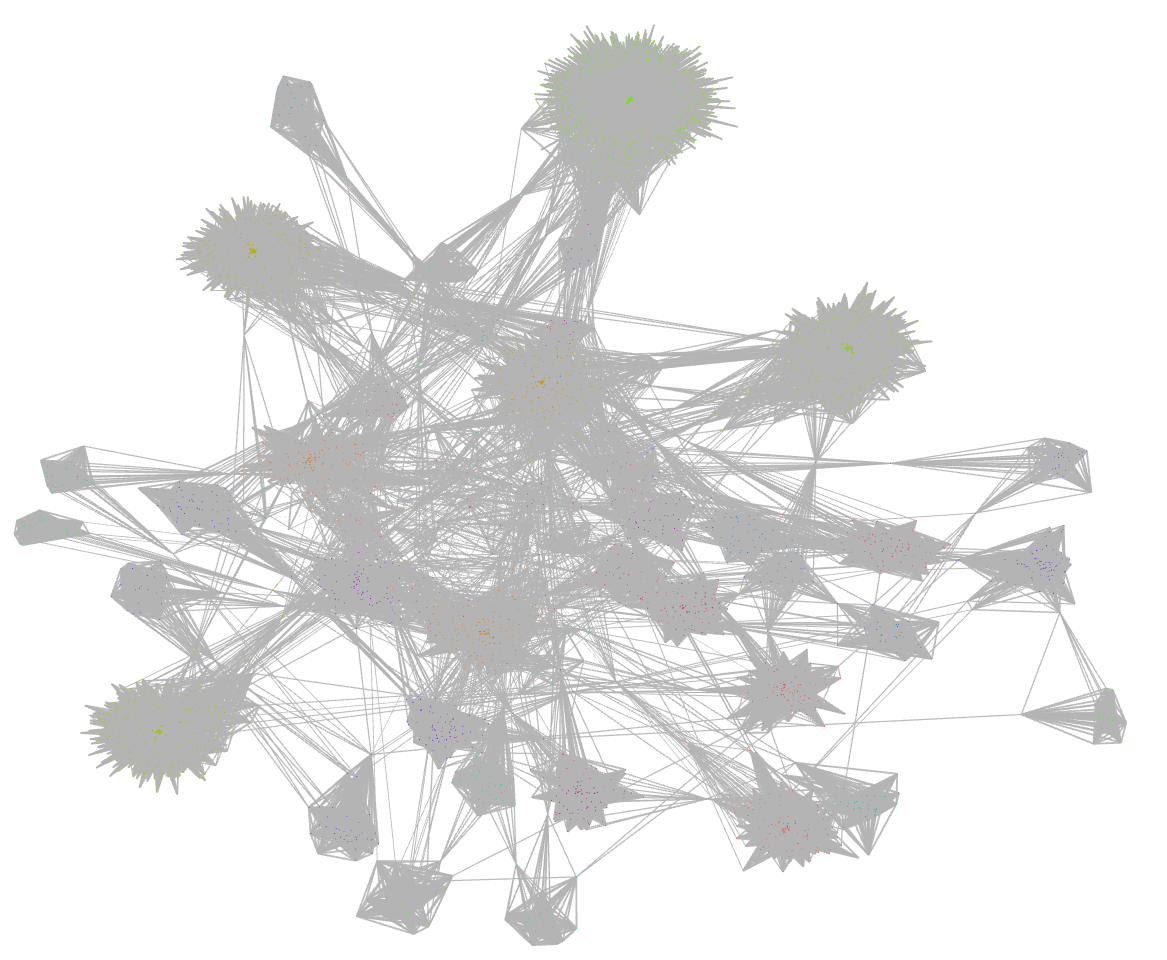

# Community-Structured Backbone Analysis

> To extract, stabilize, and interpret the mesoscale structure of the Disney Pixar Facebook comment network by progressively refining its projection, filtering statistically significant edges, and isolating cohesive interaction cores.

Before applying any filtering or community detection, I examined the structural properties of the post–post projection network built from shared commenters

In [ ]:
def preflight_graph_summary(g):
    import numpy as np
    n, m = g.vcount(), g.ecount()
    print(f"[GRAPH] V={n:,} E={m:,} directed={g.is_directed()}")
    loops = sum(1 for e in g.es if e.tuple[0]==e.tuple[1])
    mult = m - len(set(tuple(sorted(e.tuple)) for e in g.es))
    print(f"  loops={loops:,} approx_multiedges={mult:,}")
    deg = np.array(g.degree())
    w = g.es["weight"] if "weight" in g.es.attributes() else [1.0]*m
    st = np.array(g.strength(weights="weight"))
    print(f"  deg  mean={deg.mean():.2f} median={np.median(deg):.2f} max={deg.max():.0f}")
    if m:
        w_arr = np.array(w, float)
        print(f"  wgt  p50={np.percentile(w_arr,50):.3g} p90={np.percentile(w_arr,90):.3g} "
              f"p99={np.percentile(w_arr,99):.3g} max={w_arr.max():.3g}")
    # giant component
    comps = g.components()
    sizes = np.array([len(c) for c in comps])
    print(f"  comps={len(sizes)} giant={sizes.max() if len(sizes) else 0} "
          f"({(sizes.max()/n*100 if len(sizes) else 0):.1f}% of nodes)")
preflight_graph_summary(g_post_c)

[GRAPH] V=62 E=705 directed=False
  loops=0 approx_multiedges=0
  deg  mean=22.74 median=17.00 max=61
  wgt  p50=0.0735 p90=0.144 p99=0.258 max=0.365
  comps=1 giant=62 (100.0% of nodes)


- The graph contains 62 posts connected by 705 undirected edges, meaning that almost every post shares at least one common user with others. The network is fully connected, with no isolated nodes, loops, or multiedges.
- The average degree of about 23 and a maximum of 61 indicate a dense interaction pattern, where a few posts attract connections to nearly all others. Edge weights (representing the intensity of overlap in commenting activity) show a moderate range, suggesting similar engagement levels across posts

Overall, the preflight summary confirms that the network is structurally coherent but relatively dense—justifying the need for a backbone extraction to highlight statistically significant relationships and uncover clearer community structures.

### Disparity Backbone (Serrano et al., 2009)

> Reduce a dense weighted network to its statistically significant skeleton, keeping only edges that are unexpectedly strong for at least one endpoint given its total strength and degree.

1. For each node, imagine its total interaction strength is uniformly split across its neighbors (null model).

2. An edge is kept if its observed weight is unlikely under this null for either endpoint (two-tailed “either endpoint significant” rule).

3. The significance level α controls strictness: smaller α → fewer, stronger edges.

Why this helps:

- It removes ubiquitous weak overlaps that blur structure in projections.

- What remains are ties that are locally exceptional, revealing clearer communities and cores.

In [144]:
# ---------------- 1) DISPARITY BACKBONE (Serrano et al., 2009) ----------------
def disparity_backbone(g: ig.Graph, alpha: float = 0.05) -> ig.Graph:
    """
    Serrano disparity backbone (two-tailed via 'either endpoint significant').
    If it yields no edges, caller should try a larger alpha (less strict) or fallbacks.
    """
    if g.vcount() == 0 or g.ecount() == 0:
        return ig.Graph(n=0)
    if "weight" not in g.es.attributes():
        g.es["weight"] = [1.0] * g.ecount()

    deg = np.array(g.degree())
    st  = np.array(g.strength(weights="weight"))
    keep = []
    for e in g.es:
        i, j = e.tuple
        if deg[i] <= 1 or deg[j] <= 1:
            continue
        w = float(e["weight"])
        pi = w / max(st[i], 1e-12)
        pj = w / max(st[j], 1e-12)
        # p-value for observing an edge >= w under uniform split null:
        # α = 1 - (1 - p)^(k-1)
        alpha_i = 1.0 - (1.0 - pi) ** (deg[i] - 1)
        alpha_j = 1.0 - (1.0 - pj) ** (deg[j] - 1)
        if min(alpha_i, alpha_j) < alpha:  # keep if significant for either endpoint
            keep.append(e.index)
    sub = g.subgraph_edges(keep, delete_vertices=True)
    sub.simplify(multiple=True, loops=True, combine_edges={"weight": "sum"})
    return sub

### Adaptive Backbone Strategy (when data vary in density)

- Sweep α: Try a sequence (e.g., 0.05 → 0.8) and take the first non-empty backbone.

- Practical target: keep ~5–30% of edges for interpretable community detection.

Fallbacks if still too sparse:

- Top-weight quantile: keep the strongest X% (e.g., ≥90th percentile) to preserve salient ties.

- Per-node top-k: keep each node’s k strongest neighbors (then symmetrize) to guarantee minimum local support.

> You always obtain a usable sparse graph, either statistically filtered (preferred) or via controlled, interpretable heuristics (quantile/top-k), suitable for downstream Leiden communities and core extraction.

In [145]:
def backbone_adaptive(g: ig.Graph, alphas=(0.05, 0.1, 0.2, 0.4, 0.6, 0.8)):
    """
    Try a sequence of α; return the first non-empty backbone.
    If all fail, fall back to simple sparsifiers:
      - weight quantile
      - per-node top-k (symmetric)
    """
    # 1) try disparity with increasing α
    for a in alphas:
        bb = disparity_backbone(g, alpha=a)
        if bb.ecount() > 0:
            print(f"[backbone] disparity α={a} → V={bb.vcount()} E={bb.ecount()}")
            return bb

    # 2) fallback A: keep edges above weight quantile (e.g., top 10%)
    if g.ecount() == 0:
        return ig.Graph(n=0)
    w = np.array(g.es["weight"]) if "weight" in g.es.attributes() else np.ones(g.ecount())
    q = np.quantile(w, 0.90)  # top 10% strongest edges
    keep_idx = [e.index for e in g.es if float(e["weight"]) >= q]
    bb_q = g.subgraph_edges(keep_idx, delete_vertices=True)
    bb_q.simplify(multiple=True, loops=True, combine_edges={"weight": "sum"})
    if bb_q.ecount() > 0:
        print(f"[backbone] fallback quantile ≥90th → V={bb_q.vcount()} E={bb_q.ecount()}")
        return bb_q

    # 3) fallback B: per-node top-k (k=10), symmetrized by max
    k = 10
    # build sparse adjacency
    idx = np.array([e.tuple for e in g.es], dtype=int)
    ww  = np.array([float(e["weight"]) for e in g.es], dtype=float)
    n   = g.vcount()
    A = sparse.coo_matrix((ww, (idx[:,0], idx[:,1])), shape=(n,n))
    A = A + A.T
    A.setdiag(0)
    A = A.tocsr()

    # top-k per row
    A = A.tolil()
    for i in range(n):
        dat = A.data[i]
        if len(dat) > k:
            ind = np.argpartition(dat, -k)[-k:]
            keepcols = set(np.array(A.rows[i])[ind].tolist())
            newr, newd = [], []
            for j, v in zip(A.rows[i], A.data[i]):
                if j in keepcols:
                    newr.append(j); newd.append(v)
            A.rows[i], A.data[i] = newr, newd
    A = A.tocsr()
    A = A.maximum(A.T)
    A.eliminate_zeros()

    # build graph from A
    ut = sparse.triu(A, 1).tocoo()
    gk = ig.Graph(n=n, edges=list(zip(ut.row.tolist(), ut.col.tolist())), directed=False)
    if ut.nnz > 0:
        gk.es["weight"] = [float(x) for x in ut.data.tolist()]
    print(f"[backbone] fallback top-k k={k} → V={gk.vcount()} E={gk.ecount()}")
    return gk


In [146]:
def preview_backbone_keep_ratio(g, alphas=(0.05,0.1,0.2,0.4,0.6,0.8)):
    import numpy as np
    gm = g.copy()
    if "weight" not in gm.es.attributes(): gm.es["weight"] = [1.0]*gm.ecount()
    baseE = gm.ecount() or 1
    for a in alphas:
        bb = disparity_backbone(gm, alpha=a)
        print(f"α={a:<4}  kept {bb.ecount():,} edges ({bb.ecount()/baseE:6.1%}) V={bb.vcount():,}")
preview_backbone_keep_ratio(g_post_c)

α=0.05  kept 0 edges (  0.0%) V=0
α=0.1   kept 0 edges (  0.0%) V=0
α=0.2   kept 24 edges (  3.4%) V=21
α=0.4   kept 162 edges ( 23.0%) V=60
α=0.6   kept 474 edges ( 67.2%) V=62
α=0.8   kept 674 edges ( 95.6%) V=62


- α = 0.05–0.10 → 0% kept
The filter is too strict; even the strongest ties don’t pass local-significance.

- α = 0.20 → 3.4% kept (24 edges, 21 nodes)
Extremely sparse; only the very strongest, exceptional overlaps remain.

- α = 0.40 → 23.0% kept (162 edges, 60 nodes) ✅
Sweet spot: enough edges to preserve structure and run community detection cleanly while removing noise.

- α = 0.60 → 67.2% kept
Quite dense again; communities risk becoming blurry.

- α = 0.80 → 95.6% kept
Near the original graph; sparsification no longer informative.

### Leiden Community Detection 

> Identify cohesive communities in the backbone network by exploring modular structures at multiple scales and ensuring robustness through repeated optimization.

The Leiden algorithm (an improved version of Louvain) detects communities by maximizing a modularity-like quality function that balances edge density within groups against the overall network structure.
However, modularity depends on a resolution parameter (γ) — lower values favor large, coarse clusters, while higher values reveal smaller, more granular communities.

Workflow:

1. Resolution sweep: The algorithm is run across several resolution values (e.g., 0.5, 1.0, 1.5, 2.0) to explore the network at different scales.

2. Multi-restart optimization: For each resolution, multiple runs with random seeds are performed. This mitigates randomness in the optimization and helps identify stable partitions that consistently achieve high quality scores.

3. Selection: Among all runs, the partition with the highest modularity score is retained as the best representation of the community structure.

This procedure ensures that the chosen community structure is not an artifact of random initialization and that its granularity (number of communities) is empirically tuned rather than arbitrarily fixed.

In [147]:
# ---------------- 2) LEIDEN WITH RESOLUTION SWEEP & MULTI-RUN STABILITY ----------------
def leiden_best_of(
    g: ig.Graph,
    resolutions=(0.5, 1.0, 1.5, 2.0),
    n_restarts: int = 8,
    random_seed: int = 42,
):
    """
    Run Leiden across a grid of resolution parameters, with several restarts each.
    Score by modularity (CPM variant via RBConfigurationVertexPartition). Pick the best.
    Returns: (best_partition, tracker_df)
    """
    rng = np.random.default_rng(random_seed)
    rows = []
    best_part = None
    best_score = -np.inf

    w = g.es["weight"] if "weight" in g.es.attributes() else None
    for r in resolutions:
        for run in range(n_restarts):
            seed = int(rng.integers(0, 1_000_000))
            part = la.find_partition(
                g,
                la.RBConfigurationVertexPartition,
                weights=w,
                resolution_parameter=r,
                seed=seed
            )
            score = part.quality()  # modularity-like quality for the chosen partition class
            rows.append({"resolution": r, "run": run, "score": score, "n_comms": len(part)})
            if score > best_score:
                best_score = score
                best_part = part

    tracker = pd.DataFrame(rows).sort_values(["score"], ascending=False)
    return best_part, tracker


def add_membership_attr(g: ig.Graph, membership, attr="community"):
    g2 = g.copy()
    g2.vs[attr] = list(map(int, membership))
    return g2


In [148]:
def preview_resolution_sweep(g, res_grid=(0.5,0.8,1.0,1.3,1.6,2.0), n_restarts=5):
    if g.ecount()==0:
        print("Empty graph after backbone → skip Leiden."); return
    best, tr = leiden_best_of(g, resolutions=res_grid, n_restarts=n_restarts)
    print(tr.groupby("resolution", dropna=False)
            .agg(n_runs=("run","count"), best=("score","max"), avg=("score","mean"), n_comms=("n_comms","median"))
            .sort_values("resolution"))
    sizes = pd.Series(best.sizes()).describe()
    print("\n[Sizes] median=",sizes["50%"], "  90th~", pd.Series(best.sizes()).quantile(0.9))
preview_resolution_sweep(g_post_c)


            n_runs       best        avg  n_comms
resolution                                       
0.5              5  59.494326  59.494326      1.0
0.8              5  28.847437  28.842393      2.0
1.0              5  16.953828  16.767167      4.0
1.3              5   8.521603   8.396564      8.0
1.6              5   3.811183   3.745488     13.0
2.0              5  -0.298201  -0.391245     17.0

[Sizes] median= 62.0   90th~ 62.0


At low γ (0.5–0.8), the network is seen as almost homogeneous, while increasing the resolution gradually exposes internal modularity. Around γ ≈ 1.0, the network splits into 4 clear communities, providing the most meaningful balance between cohesion and separation. Beyond that point, partitions become unstable and fragmented.

> In short, the resolution sweep helps reveal the “natural” scale of community organization, avoiding both over-aggregation and excessive fragmentation.

In [149]:
def preview_core_feasibility(g, k_vals=(5,10,15), s_vals=(50.0,100.0,200.0)):
    import numpy as np
    if g.ecount()==0:
        print("Empty graph → cores will be empty."); return
    deg = np.array(g.degree())
    st  = np.array(g.strength(weights="weight")) if "weight" in g.es.attributes() else deg
    print(f"deg  mean={deg.mean():.2f} p50={np.percentile(deg,50):.1f} p90={np.percentile(deg,90):.1f}")
    print(f"str  mean={st.mean():.2f}  p50={np.percentile(st,50):.1f} p90={np.percentile(st,90):.1f} p99={np.percentile(st,99):.1f}")
    for k in k_vals:
        feas = (deg>=k).sum()
        print(f"k={k:<3}  nodes ≥k: {feas:,} ({feas/len(deg)*100:.1f}%)")
    for s in s_vals:
        feas = (st>=s).sum()
        print(f"S≥{int(s):<4} nodes ≥S: {feas:,} ({feas/len(st)*100:.1f}%)")
preview_core_feasibility(g_post_c)

deg  mean=22.74 p50=17.0 p90=49.2
str  mean=1.92  p50=1.3 p90=4.4 p99=7.4
k=5    nodes ≥k: 62 (100.0%)
k=10   nodes ≥k: 62 (100.0%)
k=15   nodes ≥k: 53 (85.5%)
S≥50   nodes ≥S: 0 (0.0%)
S≥100  nodes ≥S: 0 (0.0%)
S≥200  nodes ≥S: 0 (0.0%)


The preliminary core feasibility check shows that the original post–post projection is too dense for meaningful core extraction.

- Degrees are very high (mean ≈ 23), so k=5–15 keeps nearly all nodes.

- Strength values are small (mean ≈ 1.9), making thresholds like S≥50–200 far too large—no nodes qualify.

> Core analysis should be performed after backbone filtering, where degrees and strengths drop to realistic ranges. Thresholds should then be recalibrated around the mean degree and upper strength percentiles of the backbone to reveal meaningful structural cores.

### Core Extraction: k-Core and Strength-Core Subgraphs

1. The k-core identifies the structurally dense clusters of the network — regions where all posts maintain at least k connections, revealing its topological backbone.
2. The strength-core isolates the most interaction-heavy subsets, focusing on nodes linked by the strongest shared engagement.

Together, they trace how connectivity and interaction intensity concentrate toward the network’s most cohesive core.


In [150]:
# ---------------- 3) CORE EXTRACTORS: k-CORE & STRENGTH-CORE ----------------
def k_core_subgraph(g: ig.Graph, k: int) -> ig.Graph:
    """
    Extract the maximal induced subgraph where every node has degree >= k.
    """
    core = g.copy()
    changed = True
    while changed:
        deg = np.array(core.degree())
        keep = np.where(deg >= k)[0]
        changed = (len(keep) < core.vcount())
        core = core.induced_subgraph(keep)
    core.simplify(multiple=True, loops=True, combine_edges={"weight": "sum"})
    return core


def strength_core_subgraph(g: ig.Graph, s_min: float) -> ig.Graph:
    """
    Weighted analogue: keep nodes with strength >= s_min (iteratively).
    """
    if "weight" not in g.es.attributes():
        g.es["weight"] = [1.0] * g.ecount()

    core = g.copy()
    changed = True
    while changed and core.vcount() > 0:
        st = np.array(core.strength(weights="weight"))
        keep = np.where(st >= s_min)[0]
        changed = (len(keep) < core.vcount())
        core = core.induced_subgraph(keep)
    core.simplify(multiple=True, loops=True, combine_edges={"weight": "sum"})
    return core


Finally we obtain a fully processed, interpretable network representation — starting from a dense projection, filtered to its statistically robust backbone, segmented into stable communities, and further refined into nested structural cores ready for analysis and Gephi exploration.

In [151]:
# ---------------- 4) DRIVER: backbone → leiden → cores → exports ----------------
def analyze_post_projection(
    g_post: ig.Graph,
    out_prefix,
    alpha_backbone: float = 0.05,
    res_grid=(0.5, 1.0, 1.5, 2.0),
    restarts: int = 8,
    k_vals=(5, 10),
    s_vals=(50.0, 100.0),
):
    # (a) Adaptive backbone
    g_bb = backbone_adaptive(g_post, alphas=(alpha_backbone, 0.1, 0.2, 0.4, 0.6, 0.8))
    if g_bb.vcount() == 0 or g_bb.ecount() == 0:
        print("[WARN] Backbone empty after all strategies; exporting empty shell.")
        export_gephi_autolayout_gexf(g_bb, OUT / f"{out_prefix}_EMPTY.gexf", use_communities=False)
        return {"g_backbone": g_bb, "partition": None, "sweep": pd.DataFrame(), "size_hist": pd.DataFrame()}

    # (b) Leiden best-of (guard tiny graphs)
    try:
        best_part, sweep = leiden_best_of(g_bb, resolutions=res_grid, n_restarts=restarts)
    except Exception as e:
        print(f"[WARN] Leiden failed: {e}. Falling back to multilevel.")
        best_part = g_bb.community_multilevel(weights=g_bb.es["weight"] if "weight" in g_bb.es.attributes() else None)
        sweep = pd.DataFrame([{"resolution": np.nan, "run": 0, "score": best_part.modularity, "n_comms": len(best_part)}])

    print("[LEIDEN] top results:")
    print(sweep.head(10))

    g_comm = add_membership_attr(g_bb, best_part.membership if best_part is not None else [0]*g_bb.vcount(), attr="community")
    export_gephi_autolayout_gexf(g_comm, OUT / f"{out_prefix}_bb_leiden.gexf", use_communities=True)

    # (c) size hist (guard empty)
    if best_part is not None and len(best_part) > 0:
        sizes = np.array(best_part.sizes())
        size_hist = (pd.Series(sizes).value_counts().sort_index()
                     .rename_axis("community_size").reset_index(name="num_communities"))
        print("[COMMUNITY SIZE HIST] (head)")
        print(size_hist.head(15))
        size_hist.to_csv(OUT / f"{out_prefix}_bb_leiden_size_hist.csv", index=False)
    else:
        size_hist = pd.DataFrame(columns=["community_size","num_communities"])

    # (d) cores
    g_bb.vs["degree"] = g_bb.degree()
    g_bb.vs["strength"] = g_bb.strength(weights="weight") if "weight" in g_bb.es.attributes() else g_bb.degree()

    for k in k_vals:
        gk = k_core_subgraph(g_bb, k=k)
        print(f"[k-CORE k={k}] V={gk.vcount():,} E={gk.ecount():,}")
        export_gephi_autolayout_gexf(gk, OUT / f"{out_prefix}_bb_kcore_{k}.gexf", use_communities=True)

    for s in s_vals:
        gs = strength_core_subgraph(g_bb, s_min=s)
        print(f"[STRENGTH-CORE ≥{s}] V={gs.vcount():,} E={gs.ecount():,}")
        export_gephi_autolayout_gexf(gs, OUT / f"{out_prefix}_bb_strengthcore_{int(s)}.gexf", use_communities=True)

    return {"g_backbone": g_bb, "partition": best_part, "sweep": sweep, "size_hist": size_hist}

In [152]:
artifacts = analyze_post_projection(
    g_post=g_post_c,
    out_prefix="06_post_projection_comments",
    alpha_backbone=0.4,
    res_grid=(0.7,),              # fixed at best resolution
    restarts=10,
    k_vals=(2, 3, 4),             # only meaningful levels
    s_vals=(0.05, 0.1, 0.15),       # optional, just to visualize if non-empty
)


[backbone] disparity α=0.4 → V=60 E=162
[LEIDEN] top results:
   resolution  run     score  n_comms
3         0.7    3  5.623723        4
0         0.7    0  5.605035        4
1         0.7    1  5.605035        4
4         0.7    4  5.605035        4
5         0.7    5  5.605035        4
6         0.7    6  5.605035        4
7         0.7    7  5.605035        4
9         0.7    9  5.589800        4
2         0.7    2  5.538712        4
8         0.7    8  5.510504        5
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\06_post_projection_comments_bb_leiden.gexf
[COMMUNITY SIZE HIST] (head)
   community_size  num_communities
0              11                1
1              12                1
2              16                1
3              21                1
[k-CORE k=2] V=50 E=152
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\06_post_projection_comments_bb_kcore_2.gexf
[k-CORE k=3] V=38 E=128
✅ Exported Gephi-ready (auto layout) → Pixar Rdata\Outputs\06_p

**Backbone (α = 0.4)**
The disparity filter reduces the dense projection to a 60-node, 162-edge backbone (mean degree ≈ 5.4), preserving the most statistically significant overlaps while removing diffuse ties.

**Leiden communities (resolution = 0.7)**
Multiple restarts converge on a stable partition with 4 communities.
Sizes: 21, 16, 12, 11 — balanced clusters, indicating clear mesoscale structure.

**k-core hierarchy (topological cohesion)**

k=2: V=50, E=152 → broad inner ring of mutually connected posts.

k=3: V=38, E=128 → denser core, filtering peripheral ties.

k=4: V=24, E=87 → super-core; the most structurally cohesive subset.

**Strength-core hierarchy (weighted cohesion)**

s ≥ 0.05: V=53, E=154

s ≥ 0.10: V=37, E=122


s ≥ 0.15: V=18, E=63
These layers progressively isolate interaction-heavy subsets based on edge-weight intensity.

> The pipeline reveals four coherent communities on a statistically pruned backbone, and a nested core structure (both by degree and strength) that pinpoints the central posts driving sustained, high-overlap engagement.

leiden:

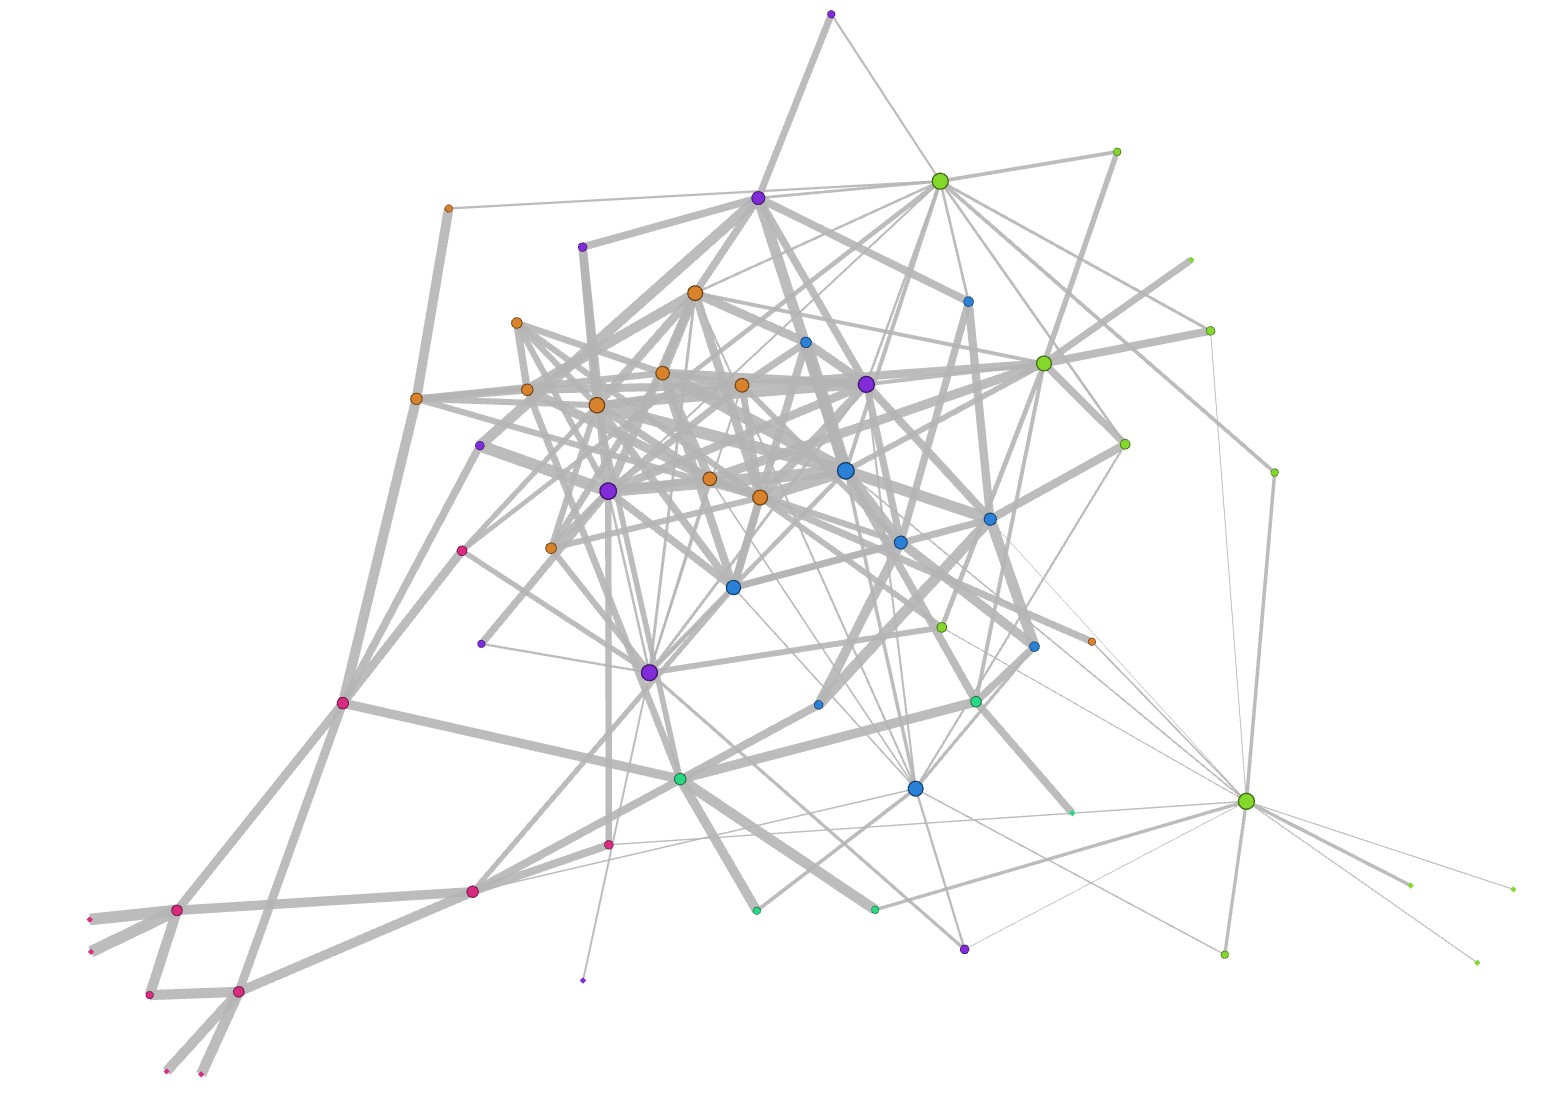

k = 2:

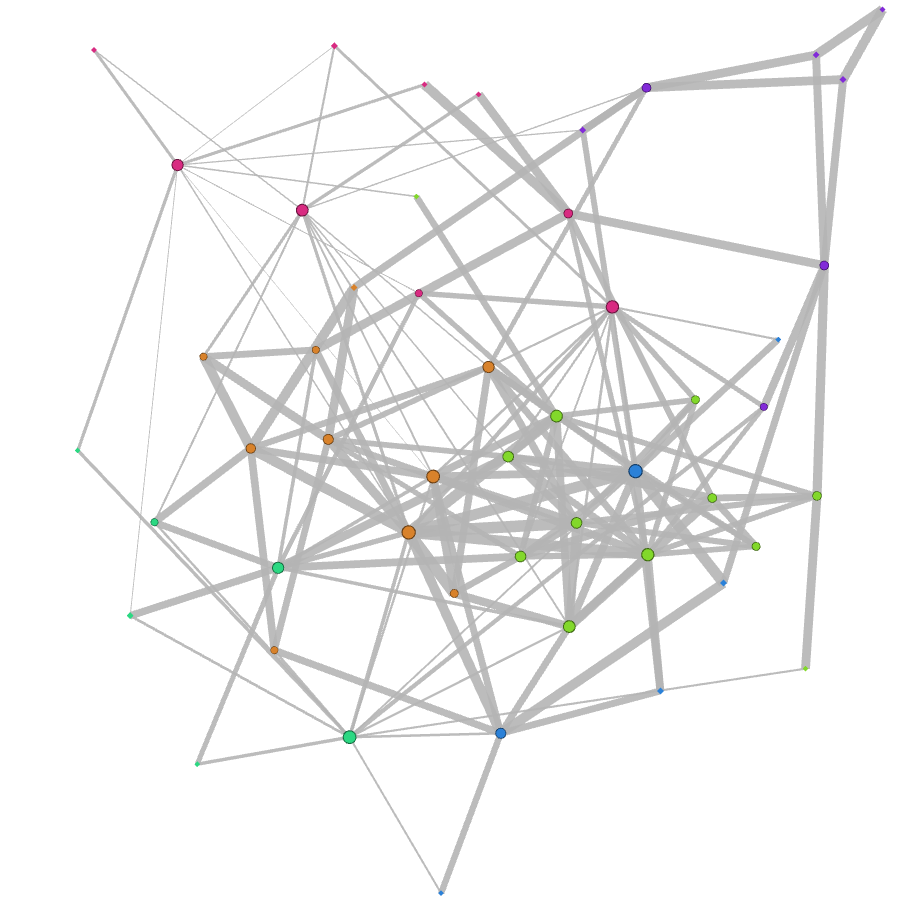

k = 3:

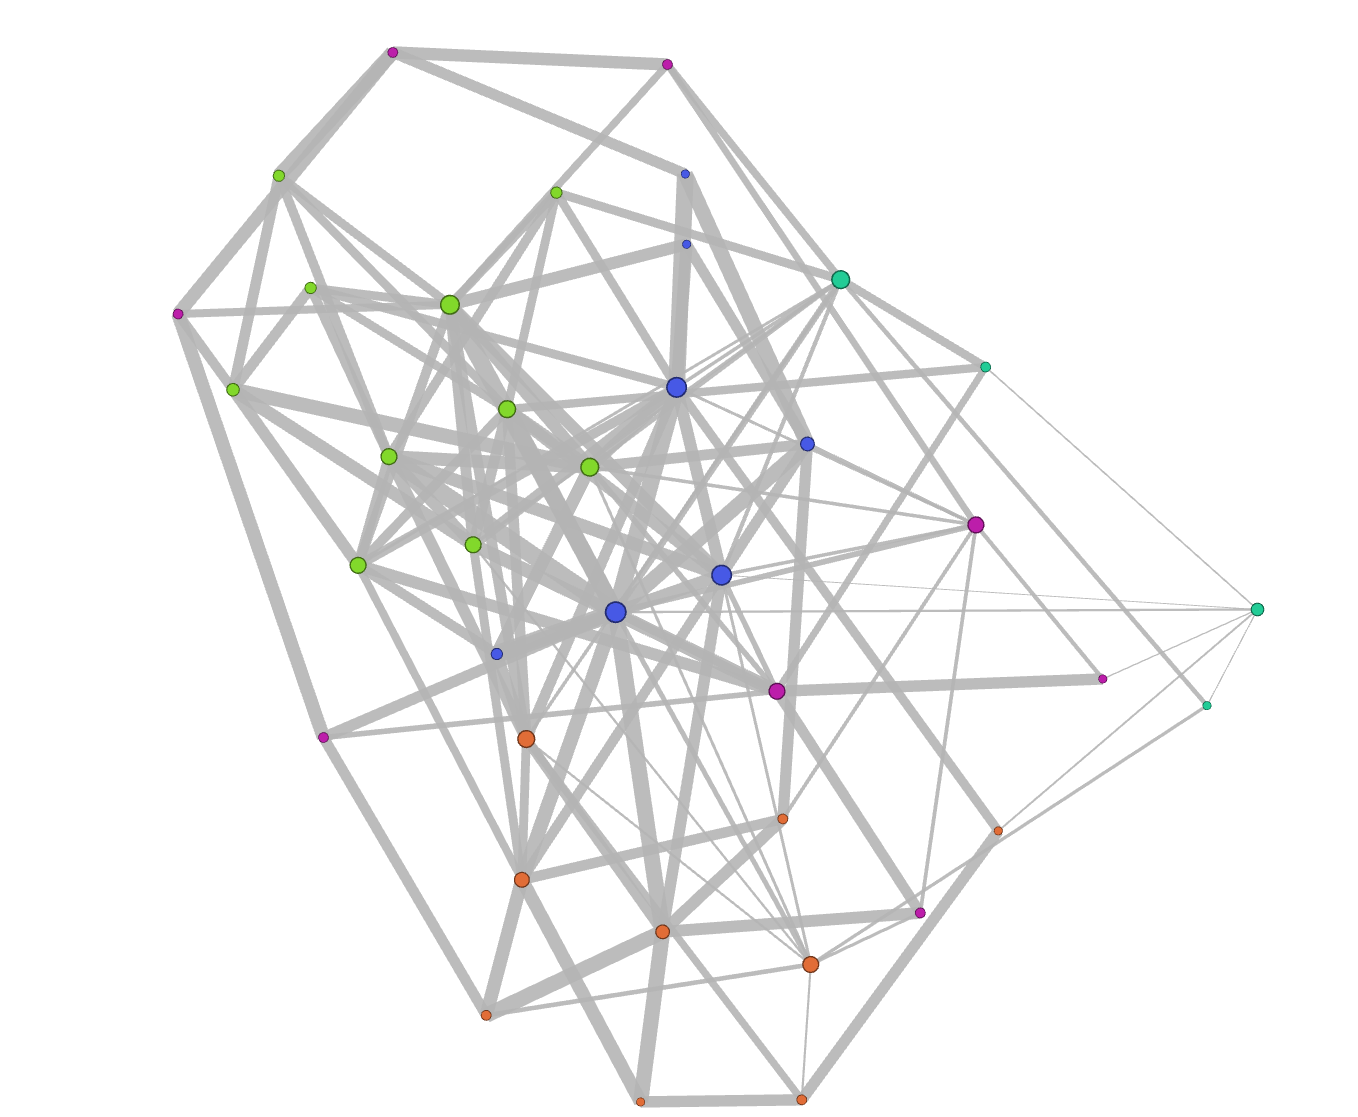

k = 4:

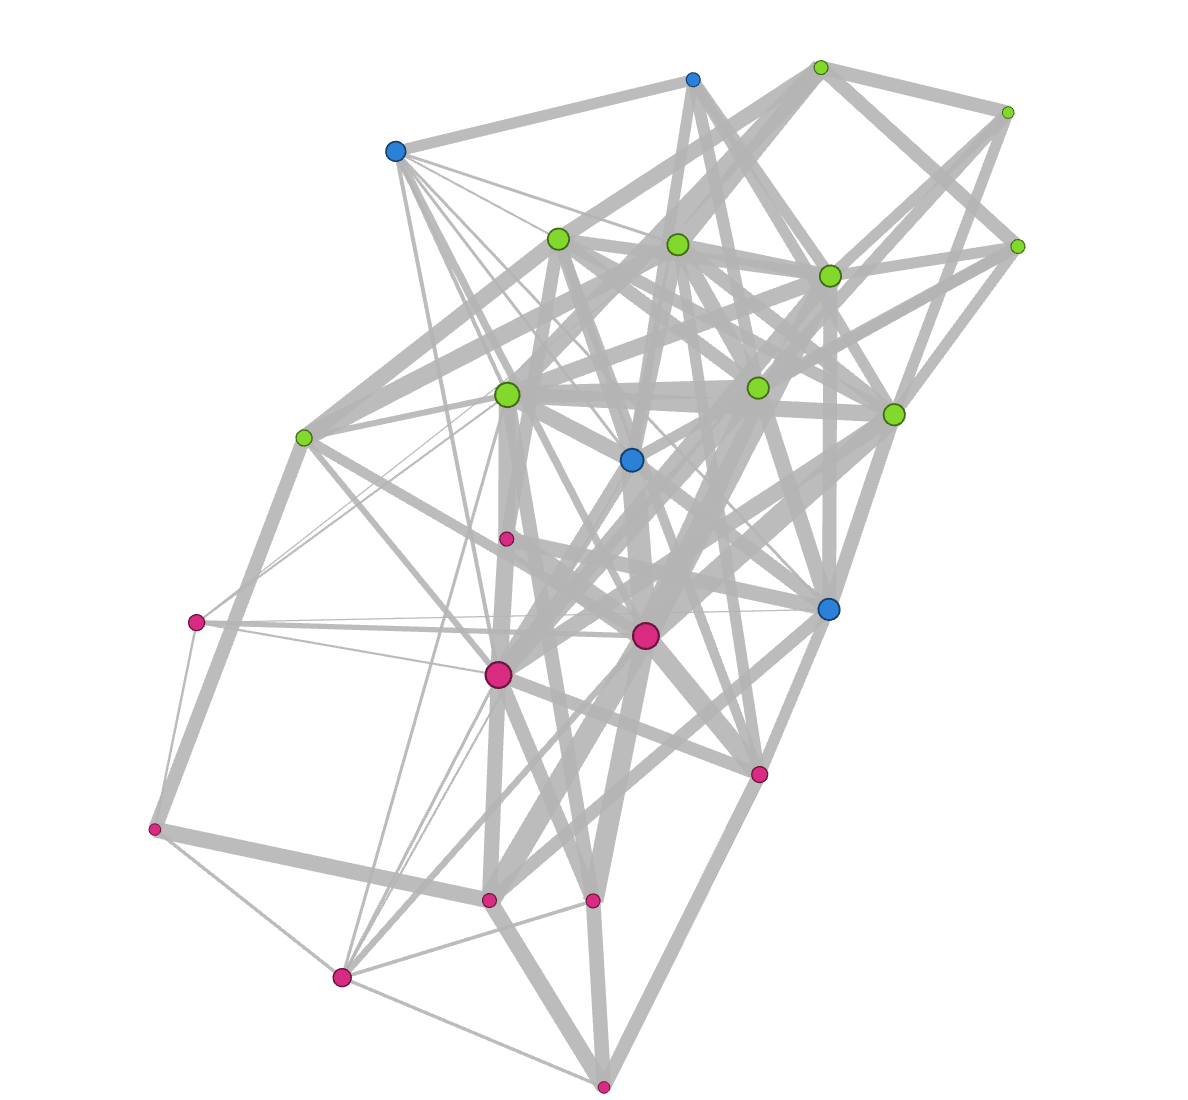

strenghtcore:

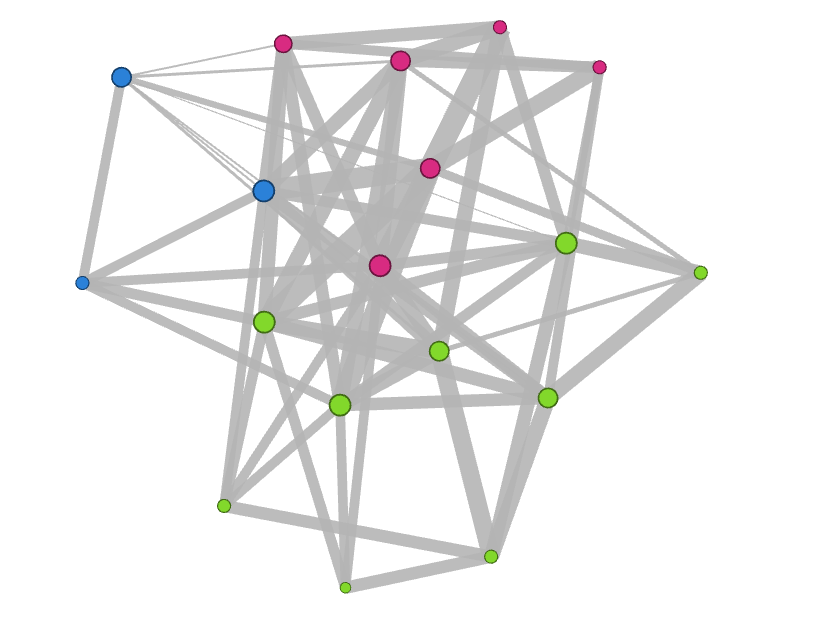